In [182]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

- 2013년이후 전국 아파트분양가격
- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [183]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 다른 폰트를 기본으로 하려면
from matplotlib.font_manager import FontProperties, fontManager
# font_path = 'C:/Windows/Fonts/HMFMPYUN.TTF'
font_path ='data/font/온글잎밑미.ttf'
fontManager.addfont(font_path)
# 폰트 다운로드 : 네이버, 구글, 눈누, 산들 등에서 ttf 파일 
font_prop = FontProperties(fname=font_path, size=20)
font_name = font_prop.get_name()

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
# plt.rc('font', family=font_name)
# plt.rc('font', size=20)
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore')

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [16]:
pd.read_csv?

In [2]:
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [19]:
pd.options.display.max_columns = 22 # 최대 display가능한 열수 수정

In [20]:
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795


In [21]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [3]:
df_first.set_index('지역', inplace=True)
df_first

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,...,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,...,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,...,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

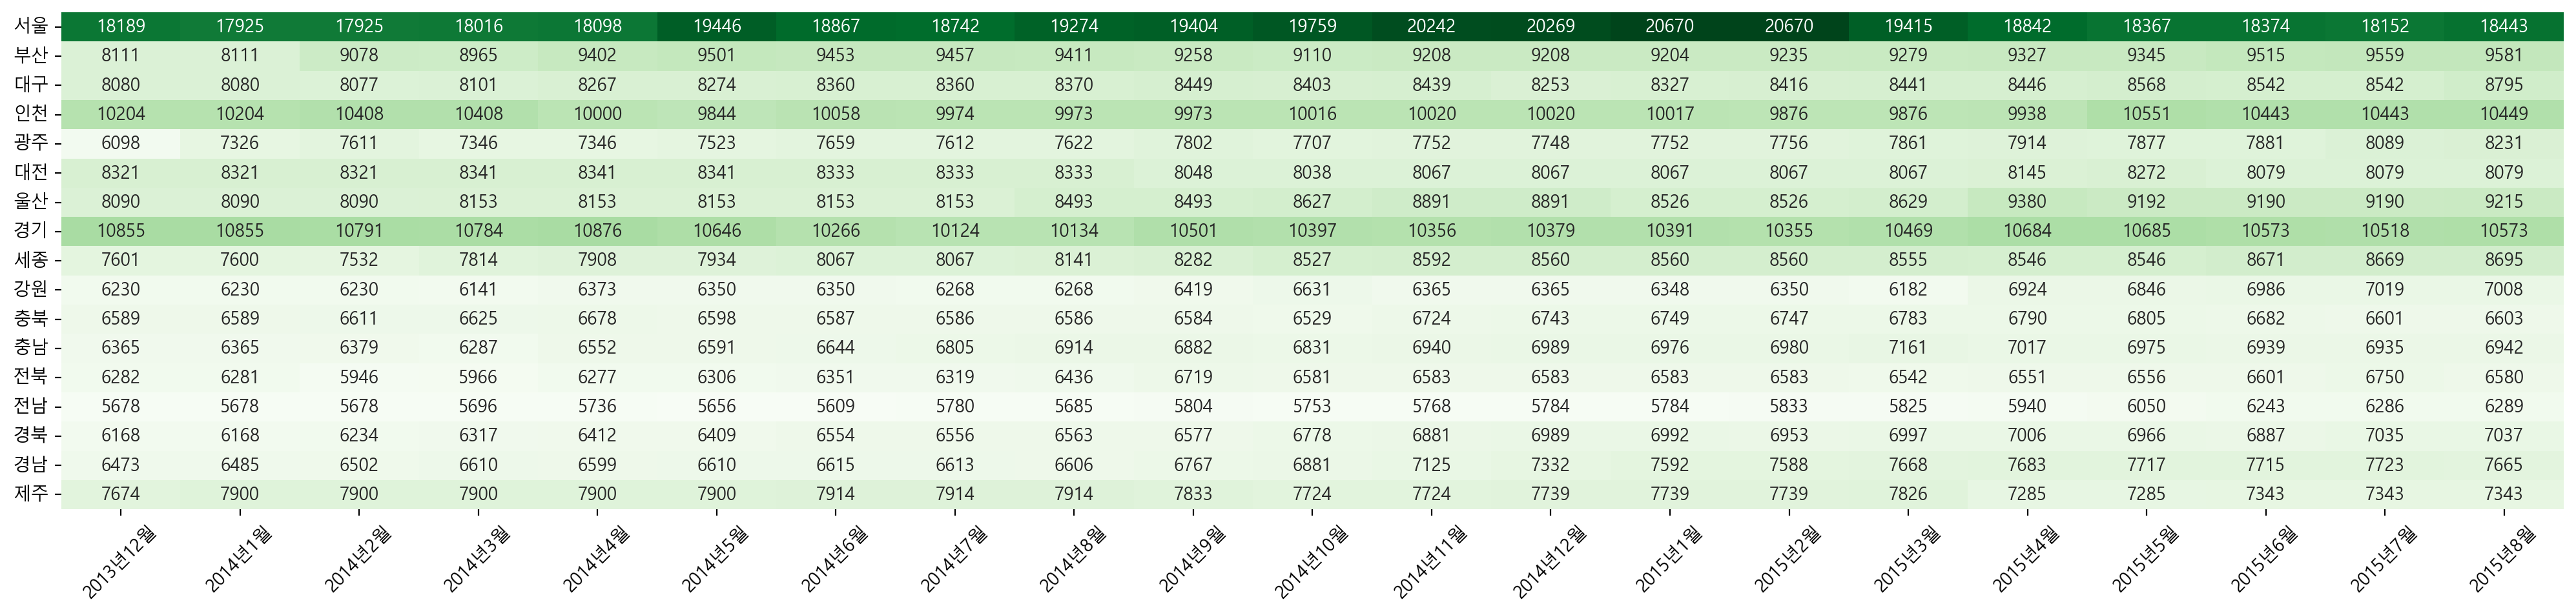

In [8]:
plt.figure(figsize=(25, 5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

## (2) 이후 데이터는 df_last 변수에 담아 탐색

In [50]:
df_last = pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                     encoding='cp949')
df_last.shape

(10880, 5)

In [4]:
df_last.tail(3)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10879,제주,전용면적 102제곱미터초과,2026,5,4350


In [14]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [15]:
df_last['분양가격(제곱미터당 천원)'].describe()

count     10035
unique     3637
top            
freq         95
Name: 분양가격(제곱미터당 천원), dtype: object

# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [52]:
# 열별 결측치 갯수
df_last.isna().sum()
df_last.isnull().sum()

지역명                 0
규모구분                0
연도                  0
월                   0
분양가격(제곱미터당 천원)    845
dtype: int64

In [54]:
# 열별 결측치를 제외한 갯수
df_last.notna().sum()
df_last.notnull().sum()

지역명               10880
규모구분              10880
연도                10880
월                 10880
분양가격(제곱미터당 천원)    10035
dtype: int64

In [13]:
# 결측치인 행 : 368,...
print('결측치인 행 :', df_last[df_last['분양가격(제곱미터당 천원)'].isna()].shape[0])
print('결측치인 행 :', len(df_last[df_last['분양가격(제곱미터당 천원)'].isna()]))

결측치인 행 : 845
결측치인 행 : 845


In [19]:
float('5841'), float(np.nan)

(5841.0, nan)

# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정 후, 형변환
## (3) df_last['분양가격(제곱미터)']*3.3

In [51]:
# df_last['분양가격(제곱미터당 천원)'].astype('float64')
temp = pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerce')
nanidx = temp[temp.isna()].index
nanidx
# 973개 = 845개(원래 nan) + 126개(' ') + 2개('-') + n개(','포함)

Int64Index([   28,    29,    34,    81,   113,   114,   119,   166,   198,
              199,
            ...
            10793, 10816, 10818, 10823, 10838, 10839, 10858, 10863, 10876,
            10878],
           dtype='int64', length=973)

In [31]:
# df_last['분양가격(제곱미터당 천원)']==' ' 인 행 : 28행, ...
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()==''].shape[0]

126

In [39]:
df_last.loc[nanidx, '분양가격(제곱미터당 천원)'].unique()

array(['  ', nan, ' ', '-'], dtype=object)

In [40]:
# df_last['분양가격(제곱미터당 천원)']== '-'인 행 :8861행, 8863행
df_last[df_last['분양가격(제곱미터당 천원)']=='-']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
8861,대구,전용면적 60제곱미터이하,2024,6,-
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-


### apply
- apply(func, axis) : 1차원, 2차원(axis지정. 기본값0=열단위작업,1=행단위작업)

In [41]:
# 콤마가 있는 문자에서 콤마 없애기 방법
temp = '5,000'
temp.replace(',','')

'5000'

In [45]:
df_last.loc[368]

지역명                                    광주
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2016
월                                       2
분양가격(제곱미터당 천원)                        NaN
Name: 368, dtype: object

In [59]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    row = row.copy()
    price = row['분양가격(제곱미터당 천원)']
    # np.isnan(스칼라값) : 값이 숫자일 경우만 에러나지 않고, np.nan 결측치 여부 반환
    # pd.isna(스칼라값), pd.isnull(값) : 값의 타입에 상관없이 np.nan과 None인지 여부 반환
    if pd.isna(price): # 결측치인지 여부
        row['제곱미터당분양가격'] = np.nan
    elif price.strip() == '' or price=='-' : # space거나 -이면 결측치
        row['제곱미터당분양가격'] = np.nan
    elif price.find(',') != -1: # price에 ,가 포함되었는지
        row['제곱미터당분양가격'] = float(price.replace(',',''))
    else:
        row['제곱미터당분양가격'] = float(price)
    return row
commadrop(df_last.loc[0]) # float로 변환된 수
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
commadrop(df_last.loc[368]) # nan의 경우 nan
commadrop(df_last.loc[8863]) # -의 경우 nan

지역명                                    대구
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2024
월                                       6
분양가격(제곱미터당 천원)                          -
제곱미터당분양가격                             NaN
Name: 8863, dtype: object

In [61]:
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용
df_last = df_last.apply(commadrop, axis=1)
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당분양가격
0,서울,모든면적,2015,10,5841,5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0


In [62]:
df_last[['분양가격(제곱미터당 천원)','제곱미터당분양가격']].isna().sum()

분양가격(제곱미터당 천원)    845
제곱미터당분양가격         973
dtype: int64

### map
- map(func) : 1차원

In [63]:
df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
936,서울,전용면적 60제곱미터이하,2016,9,6565


In [69]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    # np.isnan(스칼라값) : 값이 숫자일 경우만 에러나지 않고, np.nan 결측치 여부 반환
    # pd.isna(스칼라값), pd.isnull(값) : 값의 타입에 상관없이 np.nan과 None인지 여부 반환
    if pd.isna(price): # 결측치인지 여부
        return np.nan
    elif price.strip() == '' or price=='-' : # space거나 -이면 결측치
        return np.nan
    elif price.find(',') != -1: # price에 ,가 포함되었는지
        return float(price.replace(',',''))
    else:
        return float(price)

commadrop2(df_last.loc[0, '분양가격(제곱미터당 천원)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터당 천원)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터당 천원)']) # nan을 nan
commadrop2(df_last.loc[8863, '분양가격(제곱미터당 천원)']) # -를 nan

nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [77]:
#df_last['분양가격(제곱미터당 천원)'].apply(commadrop2)
df_last['제곱미터당분양가격'] = df_last['분양가격(제곱미터당 천원)'].map(commadrop2)
df_last.iloc[8863:8866]

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당분양가격
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-,NaN
8864,대구,전용면적 102제곱미터초과,2024,6,5593,5593.0
8865,광주,모든면적,2024,6,5471,5471.0


### apply나 map사용 안하기

In [81]:
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''), errors='coerce').isna().sum()

973

In [83]:
df_last['제곱미터당분양가격'] = \
        pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''), errors='coerce')
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 510.1+ KB


In [84]:
# 형변환 후 평당분양가격(제곱미터당분양가격 * 3.3)
df_last['평당분양가격'] = df_last['제곱미터당분양가격'] * 3.3
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
 6   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [85]:
df_last[['제곱미터당분양가격','평당분양가격']].describe() # 요약 통계량

,제곱미터당분양가격,평당분양가격
count,9907.000000,9907.000000
mean,4291.544867,14162.098062
std,2125.581720,7014.419675
min,1868.000000,6164.400000
25%,2872.000000,9477.600000
50%,3798.000000,12533.400000
75%,4940.500000,16303.650000
max,22713.000000,74952.900000


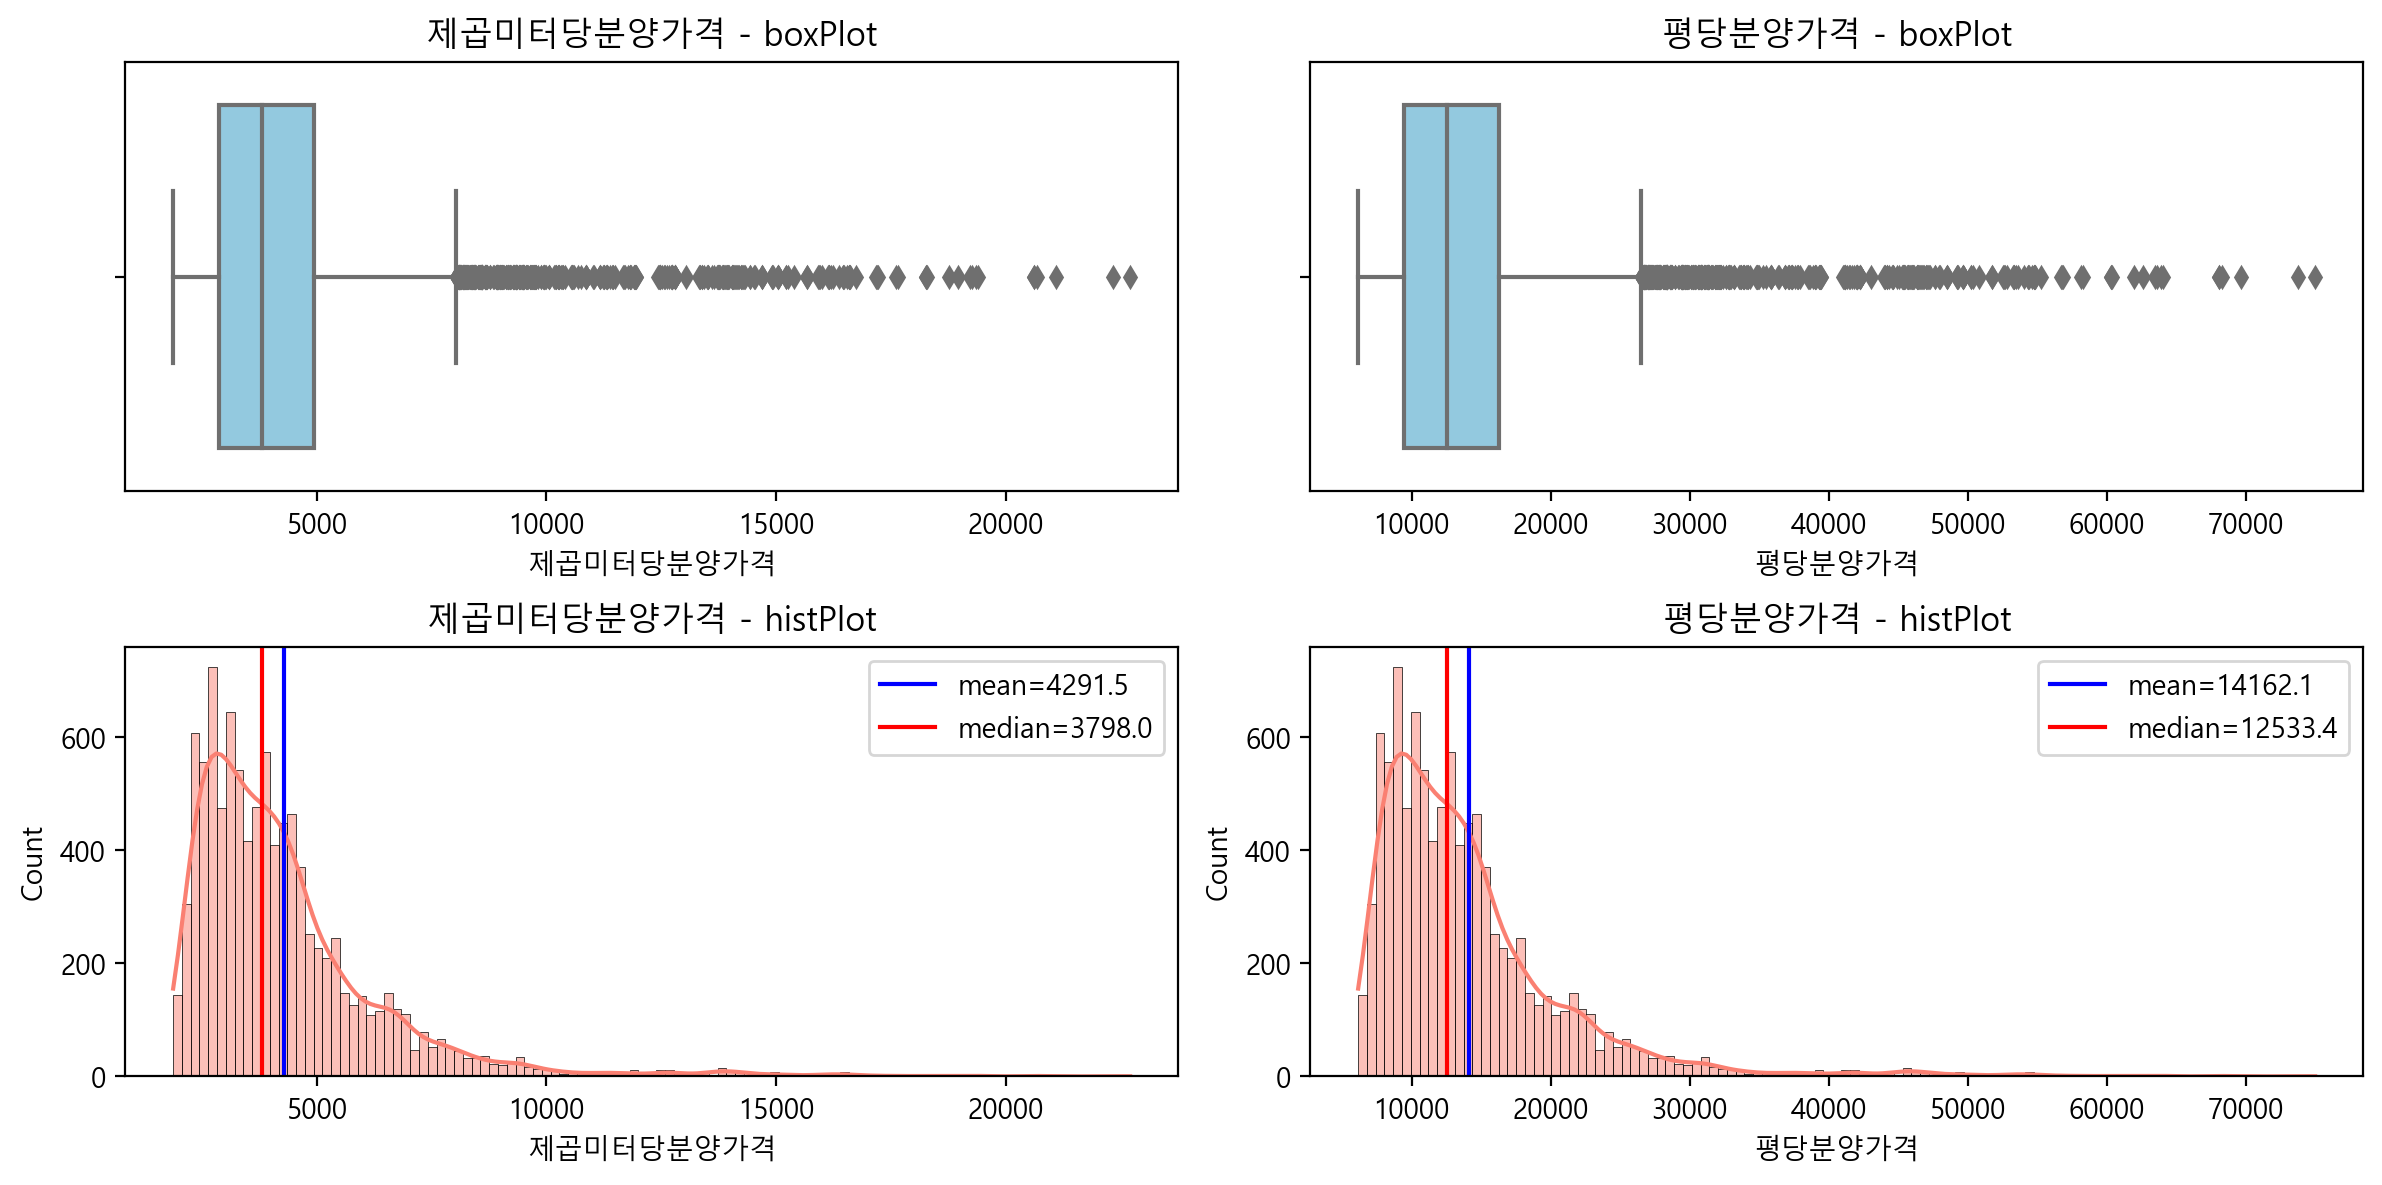

In [99]:
cols = ['제곱미터당분양가격','평당분양가격']
fig, axes = plt.subplots(nrows=2, ncols=len(cols), figsize=(12, 6))
for i, col in enumerate(cols):
    # 0행 boxplot
    sns.boxplot(data=df_last, x=col, ax=axes[0, i], color='skyblue')
    axes[0,i].set_title(f'{col} - boxPlot')
    # 1행 histplot
    sns.histplot(df_last[col], ax=axes[1, i], color='salmon', kde=True)
    axes[1,i].set_title(f'{col} - histPlot')
    # 평균(mean)과 중위수(median)를 histplot 표시
    mean_val = df_last[col].mean()
    median_val = df_last[col].median()
    axes[1, i].axvline(mean_val, color='blue', label=f'mean={mean_val:.1f}')
    axes[1, i].axvline(median_val, color='red', label=f'median={median_val:.1f}')
    axes[1, i].legend()
plt.tight_layout()

In [101]:
# 왜도(skewness) : 분포가 좌우로 얼마나 비대칭인지를 수치로 나타내는 지표
# 왜도 = 0 : 좌우대칭 / |왜도| < 0.5 : 거의 대칭
# 왜도 > 0 : 오른쪽 꼬리 긴 분포(mean > median)
# 왜도 < 0 : 왼쪽 꼬리 긴 분포 (mean < median)
df_last[['제곱미터당분양가격','평당분양가격']].skew()

제곱미터당분양가격    2.582328
평당분양가격       2.582328
dtype: float64

# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [103]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
 6   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [105]:
df_last['규모구분'].unique()

array(['모든면적', '전용면적 60제곱미터이하', '전용면적 60제곱미터초과 85제곱미터이하',
       '전용면적 85제곱미터초과 102제곱미터이하', '전용면적 102제곱미터초과'], dtype=object)

In [118]:
# ² : alt+0178 Alt떼기 ²
# 전용면적 60제곱미터초과 85제곱미터이하 => 60m~85m
# 전용면적 60제곱미터이하 => 65m
# 전용면적 102제곱미터초과 => 102m~
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','').str.replace('이하','')
df_last['전용면적'] = df_last['전용면적'].str.replace('제곱미터','m').str.replace('초과','~')
df_last['전용면적'] = df_last['전용면적'].str.replace(' ','')

In [121]:
print(df_last['전용면적'].unique())
print(df_last['규모구분'].unique())

['모든면적' '60m' '60m~85m' '85m~102m' '102m~']
['모든면적' '전용면적 60제곱미터이하' '전용면적 60제곱미터초과 85제곱미터이하' '전용면적 85제곱미터초과 102제곱미터이하'
 '전용면적 102제곱미터초과']


# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [124]:
df_last.drop(['규모구분','분양가격(제곱미터당 천원)','제곱미터당분양가격'], axis=1, inplace=True) # 열삭제 후 데이터
df_last.head(1)

,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,모든면적


In [127]:
# df_last = df_last[['지역명','전용면적','연도','월','평당분양가격']]
# df_last.reindex(columns=['지역명','전용면적','연도','월','평당분양가격'])
col = df_last.pop('전용면적') # 열삭제 후 삭제된 열을 return
print(col)
df_last

0            모든면적
1             60m
2         60m~85m
3        85m~102m
4           102m~
           ...   
10875        모든면적
10876         60m
10877     60m~85m
10878    85m~102m
10879       102m~
Name: 전용면적, Length: 10880, dtype: object


,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
1,서울,2015,10,18651.6
2,서울,2015,10,19410.6
3,서울,2015,10,18879.3
4,서울,2015,10,19400.7
...,...,...,...,...
10875,제주,2026,5,14760.9
10876,제주,2026,5,NaN
10877,제주,2026,5,14800.5
10878,제주,2026,5,NaN


In [128]:
df_last.insert(1, '전용면적', col)
df_last.head()

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,60m,2015,10,18651.6
2,서울,60m~85m,2015,10,19410.6
3,서울,85m~102m,2015,10,18879.3
4,서울,102m~,2015,10,19400.7


In [129]:
df_last.info() # 595.1KB => 425.1KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     10880 non-null  object 
 1   전용면적    10880 non-null  object 
 2   연도      10880 non-null  int64  
 3   월       10880 non-null  int64  
 4   평당분양가격  9907 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 425.1+ KB


In [130]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

# ※

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

In [184]:
df_last = pd.read_csv('data/df_last.csv')

- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

In [135]:
# 지역별 결측치 포함한 데이터(행)수
df_last.groupby('지역명')['전용면적'].count()
df_last['지역명'].value_counts() # 정렬까지

서울    640
강원    640
경남    640
경북    640
전남    640
전북    640
충남    640
충북    640
세종    640
인천    640
울산    640
대전    640
광주    640
대구    640
부산    640
경기    640
제주    640
Name: 지역명, dtype: int64

In [145]:
# 지역별 결측치를 제외한 데이터(행)수 (groupby)
df_last.groupby('지역명')['평당분양가격'].count().sort_values(ascending=False) # 1차원
df_last.groupby('지역명')[['평당분양가격']].count().sort_values('평당분양가격', ascending=False).T # 2차원

지역명,경기,인천,부산,서울,충북,강원,전북,충남,경남,경북,전남,대구,광주,대전,울산,제주,세종
평당분양가격,640,636,635,632,630,628,619,619,609,592,589,582,545,513,496,489,453


In [144]:
# 지역별 결측치를 제외한 데이터(행)수 (pivot_table)
# pd.pivot_table(df_last, ...)
df_last.pivot_table(index='지역명', 
                    values='평당분양가격', 
                    aggfunc='count').sort_values('평당분양가격', ascending=False).T

지역명,경기,인천,부산,서울,충북,강원,전북,충남,경남,경북,전남,대구,광주,대전,울산,제주,세종
평당분양가격,640,636,635,632,630,628,619,619,609,592,589,582,545,513,496,489,453


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [149]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)

지역명
서울    31416.731013
경기    16675.776562
부산    16658.924882
제주    16536.995092
대구    15951.406186
인천    15378.612264
울산    14932.213911
대전    14177.752047
광주    14003.631743
세종    11442.134437
경남    11322.646798
강원    10998.011943
경북    10838.521115
충남    10492.272698
전남     9784.729711
충북     9765.255238
전북     9568.656543
Name: 평당분양가격, dtype: float64

In [159]:
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   #aggfunc='mean'
                   ).sort_values(by='평당분양가격', 
                                 ascending=False).applymap(lambda x:int(round(x))).T

지역명,서울,경기,부산,제주,대구,인천,울산,대전,광주,세종,경남,강원,경북,충남,전남,충북,전북
평당분양가격,31417,16676,16659,16537,15951,15379,14932,14178,14004,11442,11323,10998,10839,10492,9785,9765,9569


In [161]:
# 지역별 요약 통계량(describe)
df_last.groupby('지역명')['평당분양가격'].describe()

,count,mean,std,min,25%,50%,75%,max
지역명,,,,,,,,
강원,628.0,10998.011943,3425.702338,6639.6,7877.100,10269.60,14201.550,31016.7
경기,640.0,16675.776562,4178.250807,10160.7,13600.125,15486.90,20549.925,28960.8
경남,609.0,11322.646798,2457.789421,7260.0,9428.100,10596.30,13460.700,18196.2
경북,592.0,10838.521115,2589.517973,6949.8,8507.400,10292.70,13299.000,17160.0
광주,545.0,14003.631743,4244.071441,7428.3,10045.200,13919.40,17239.200,39029.1
대구,582.0,15951.406186,5304.075909,8259.9,12412.125,15387.90,17019.750,42220.2
대전,513.0,14177.752047,5212.274642,8002.5,10101.300,13427.70,17351.400,52813.2
부산,635.0,16658.924882,5948.934616,9669.0,12647.250,14265.90,20676.150,42220.2
서울,632.0,31416.731013,10674.077285,16701.3,23064.525,28297.50,35818.200,74952.9


In [171]:
r = df_last.pivot_table(index=['지역명'],
                   #values = '평당분양가격',
                   values=['평당분양가격'],
                   aggfunc='describe',
                   ).round(2)
r.columns = r.columns.droplevel(0)
r

,25%,50%,75%,count,max,mean,min,std
지역명,,,,,,,,
강원,7877.10,10269.60,14201.55,628.0,31016.7,10998.01,6639.6,3425.70
경기,13600.12,15486.90,20549.92,640.0,28960.8,16675.78,10160.7,4178.25
경남,9428.10,10596.30,13460.70,609.0,18196.2,11322.65,7260.0,2457.79
경북,8507.40,10292.70,13299.00,592.0,17160.0,10838.52,6949.8,2589.52
광주,10045.20,13919.40,17239.20,545.0,39029.1,14003.63,7428.3,4244.07
대구,12412.12,15387.90,17019.75,582.0,42220.2,15951.41,8259.9,5304.08
대전,10101.30,13427.70,17351.40,513.0,52813.2,14177.75,8002.5,5212.27
부산,12647.25,14265.90,20676.15,635.0,42220.2,16658.92,9669.0,5948.93
서울,23064.52,28297.50,35818.20,632.0,74952.9,31416.73,16701.3,10674.08


## (3) 전용면적별 평당분양가격(평균)

In [177]:
df_last.groupby('전용면적')['평당분양가격'].mean().sort_values(ascending=False) # 1차원
df_last.groupby('전용면적')['평당분양가격'].mean().sort_values(ascending=False).to_frame() # 2차원
df_last.groupby('전용면적')[['평당분양가격']].mean().sort_values('평당분양가격',ascending=False) # 2차원

,평당분양가격
전용면적,
102m~,15348.875445
85m~102m,14554.491727
모든면적,13783.366324
60m~85m,13710.910108
60m,13553.346590


In [178]:
df_last.pivot_table(index='전용면적',
                   values='평당분양가격').sort_values('평당분양가격',ascending=False)

,평당분양가격
전용면적,
102m~,15348.875445
85m~102m,14554.491727
모든면적,13783.366324
60m~85m,13710.910108
60m,13553.346590


## (4) 지역별, 전용면적별 평당분양가격(평균)

In [192]:
r = df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean()
print(r['경기'])
print(r['경기','102m~'])

전용면적
102m~       17356.195312
60m         16698.567188
60m~85m     16133.313281
85m~102m    17134.992188
모든면적        16055.814844
Name: 평당분양가격, dtype: float64
17356.1953125


In [196]:
# unstack() : level 0인덱스는 그대로 두고, level1인덱스를 컬럼으로 
df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean().unstack().round(1)

전용면적,102m~,60m,60m~85m,85m~102m,모든면적
지역명,,,,,
강원,12190.7,10464.9,10286.3,11665.6,10445.2
경기,17356.2,16698.6,16133.3,17135.0,16055.8
경남,12082.5,10691.0,10797.9,12413.3,10839.9
경북,11742.0,10121.0,10522.8,11291.5,10567.7
광주,16202.9,13326.4,13423.3,12827.0,13765.7
대구,17564.8,14179.6,16225.5,14912.8,16465.5
대전,19627.5,12670.0,12886.5,15295.8,12978.5
부산,17994.7,15796.0,16148.7,17111.1,16275.5
서울,33909.5,30757.8,30337.0,31872.7,30330.7


In [200]:
r = df_last.pivot_table(index=['지역명','전용면적'],
                   values='평당분양가격',
                  # aggfunc='mean'
                   ).unstack()
r.columns = r.columns.droplevel(0)
r

전용면적,102m~,60m,60m~85m,85m~102m,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750
대구,17564.800000,14179.645872,16225.545600,14912.832000,16465.521600
대전,19627.533750,12669.992500,12886.525781,15295.847368,12978.487500
부산,17994.742857,15796.017187,16148.653125,17111.133600,16275.548437
서울,33909.528689,30757.778906,30337.003125,31872.657143,30330.660938


In [206]:
r = df_last.pivot_table(index='지역명',
                   columns='전용면적',
                   values='평당분양가격').reindex(columns=['60m','60m~85m','85m~102m','102m~','모든면적'])
#r = r[['60m','60m~85m','85m~102m','102m~','모든면적']]
r

전용면적,60m,60m~85m,85m~102m,102m~,모든면적
지역명,,,,,
강원,10464.867188,10286.306250,11665.613793,12190.664062,10445.196094
경기,16698.567188,16133.313281,17134.992188,17356.195312,16055.814844
경남,10690.978571,10797.883594,12413.298165,12082.530508,10839.932812
경북,10120.955263,10522.849219,11291.545361,11741.980800,10567.682812
광주,13326.445000,13423.291406,12826.980000,16202.855263,13765.743750
대구,14179.645872,16225.545600,14912.832000,17564.800000,16465.521600
대전,12669.992500,12886.525781,15295.847368,19627.533750,12978.487500
부산,15796.017187,16148.653125,17111.133600,17994.742857,16275.548437
서울,30757.778906,30337.003125,31872.657143,33909.528689,30330.660938


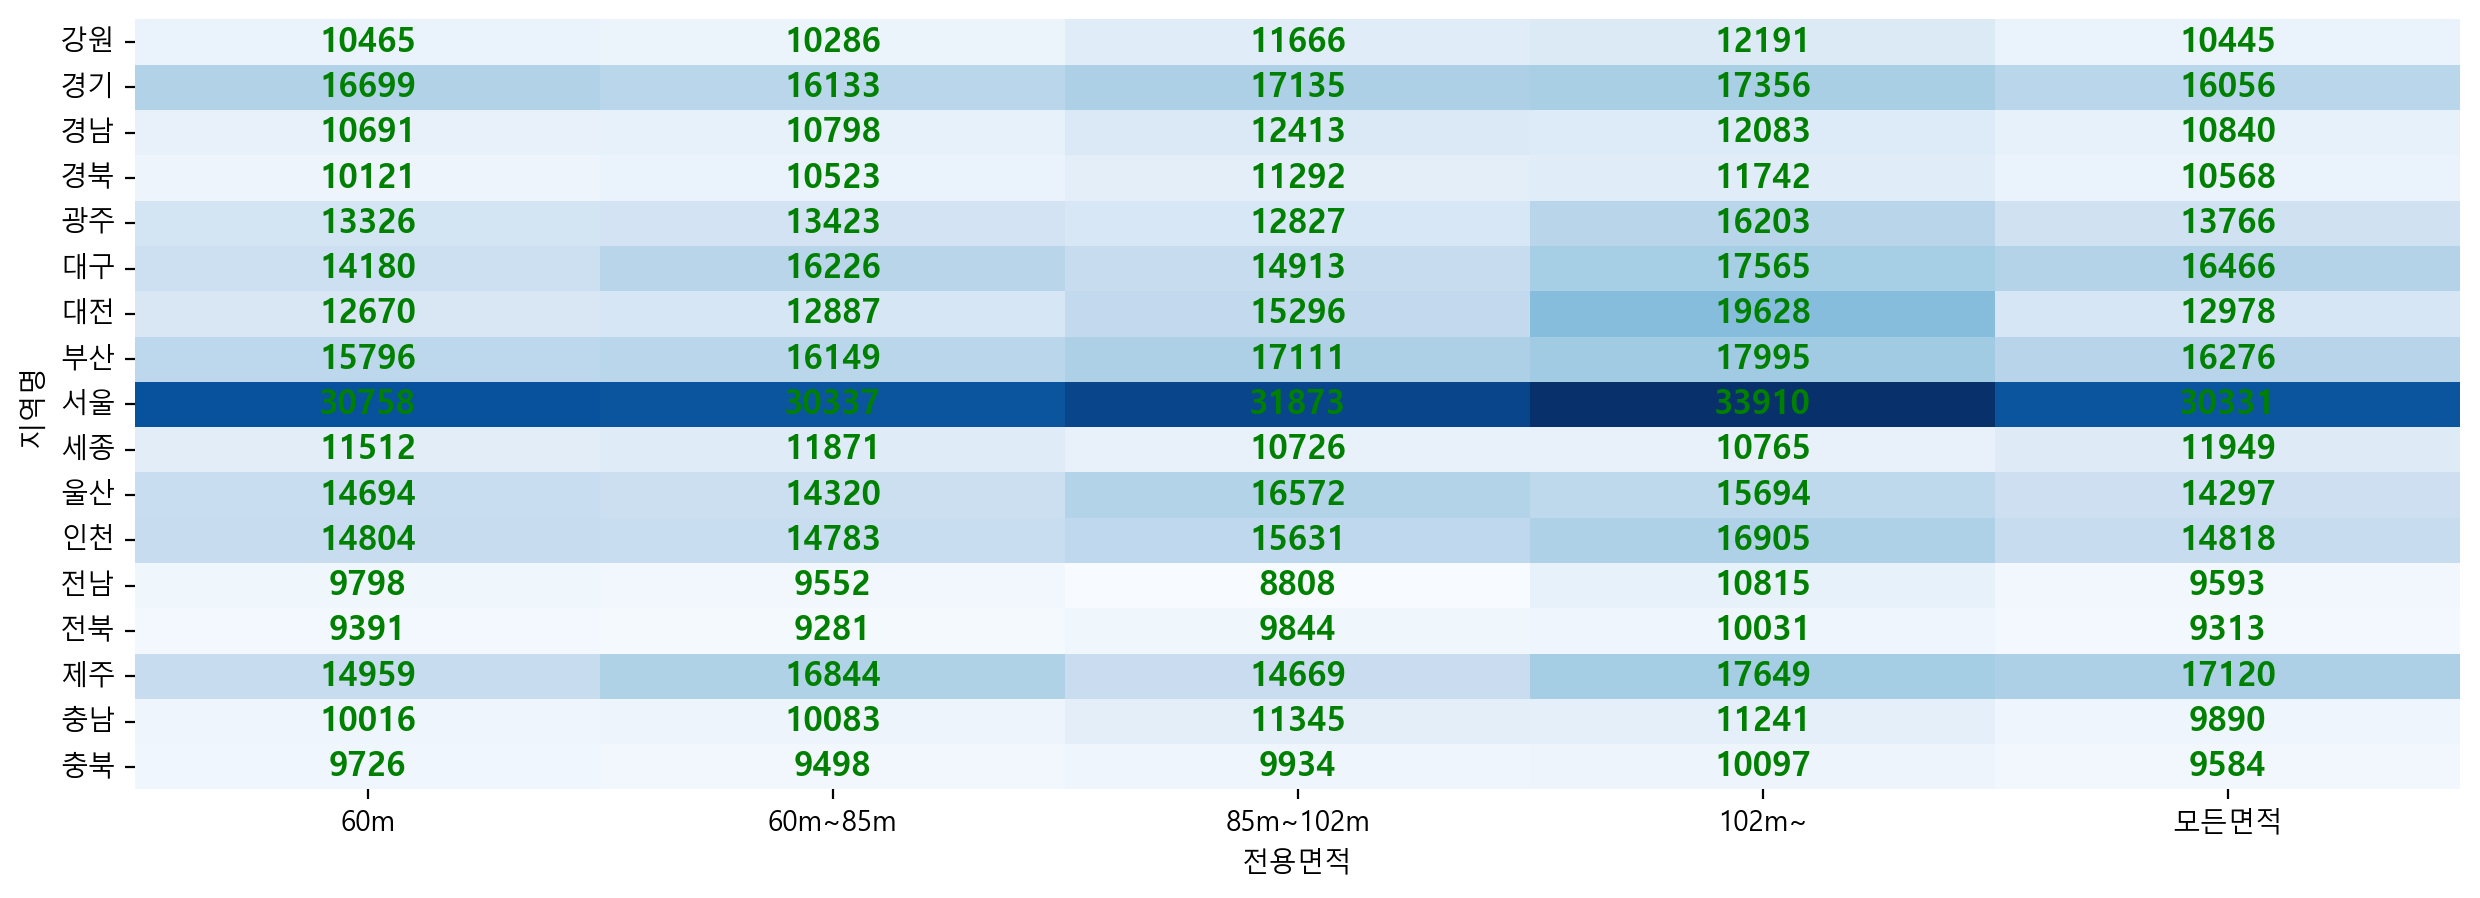

In [217]:
plt.figure(figsize=(15,5))
sns.heatmap(r, annot=True, fmt='.0f', cmap='Blues',
           annot_kws={'color':'green', 'size':12, 'weight':'bold'},
           cbar=False)
plt.show()

## (5) 연도, 지역별 평당분양가격(평균)

In [220]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     10880 non-null  object 
 1   전용면적    10880 non-null  object 
 2   연도      10880 non-null  int64  
 3   월       10880 non-null  int64  
 4   평당분양가격  9907 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 425.1+ KB


In [223]:
r = df_last.groupby(['연도','지역명'])['평당분양가격'].mean()
print(r)
print(r[2026])
print(r[2025,'서울'])

연도    지역명
2015  강원      7188.060000
      경기     11060.940000
      경남      8459.220000
      경북      7464.160000
      광주      7916.700000
                 ...     
2026  전남     13109.336842
      전북     13345.026316
      제주     14658.988235
      충남     14843.400000
      충북     14814.492000
Name: 평당분양가격, Length: 204, dtype: float64
지역명
강원    17124.096000
경기    22455.180000
경남    15143.040000
경북    14020.462500
광주    21460.594737
대구    31924.394118
대전    18961.800000
부산    28490.484000
서울    50800.728000
세종    18236.964706
울산    19058.073913
인천    26430.228000
전남    13109.336842
전북    13345.026316
제주    14658.988235
충남    14843.400000
충북    14814.492000
Name: 평당분양가격, dtype: float64
47415.225


In [224]:
df_last.groupby(['연도','지역명'])['평당분양가격'].mean().unstack()

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.060000,11060.940,8459.220000,7464.160000,7916.700000,9018.900000,8190.600000,10377.400000,20315.680000,8765.020000,9367.600000,10976.020000,6798.880000,7110.400000,7951.075000,7689.880000,6828.800000
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535000,21753.435000,8857.805000,9582.574138,11099.055000,6936.600000,6906.625000,9567.480000,7958.225000,7133.335000
2017,7318.850000,12296.185,8806.600000,8288.063793,9599.700000,12191.972222,9912.910526,11637.615000,21864.095000,9132.945763,10630.160870,11672.430000,7413.230000,7406.126316,12628.539623,8157.315517,7462.565000
2018,8219.255000,14258.420,9327.670000,8680.776923,9526.953333,12139.252632,10234.106667,12889.965000,23202.245000,10340.463158,10241.400000,11881.532143,7929.845000,8174.595000,11935.968000,8201.820000,8149.295000
2019,8934.475000,15665.540,10697.615789,9050.250000,12111.675000,14081.650000,12619.200000,13537.865000,28286.830000,11299.394118,10216.250000,13249.775000,8219.275862,8532.260000,11828.469231,8748.840000,7970.875000
2020,10302.423214,15106.080,10919.272222,9997.693750,13406.485714,15314.200000,11238.844737,13353.010000,29781.015000,11628.100000,12837.600000,14982.990000,9562.398214,8559.430000,14192.876923,9139.380000,8358.956897
2021,10291.325000,14567.080,11302.335000,11227.150000,13709.850000,15586.285000,11994.216667,14317.655000,29380.450000,12578.060000,14191.953061,15774.330000,9980.760000,9047.928814,22302.342857,9860.741379,8822.385000
2022,11644.215000,16621.550,12455.685000,12018.050000,15095.885106,16821.915000,14113.880000,18166.835593,29128.531034,11309.971698,17903.751724,17341.830000,10635.508475,10003.070000,18953.825000,11730.345000,10033.540000
2023,13409.385000,20175.210,13283.182759,13025.320000,17957.852830,17656.747059,17917.288889,20470.850847,33230.560000,12278.200000,18832.093220,16150.695000,11846.682692,10966.024528,24095.901923,12580.590000,11103.950000


In [228]:
r = df_last.pivot_table(index='연도',
                   columns='지역명',
                   values='평당분양가격')
r

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.060000,11060.940,8459.220000,7464.160000,7916.700000,9018.900000,8190.600000,10377.400000,20315.680000,8765.020000,9367.600000,10976.020000,6798.880000,7110.400000,7951.075000,7689.880000,6828.800000
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535000,21753.435000,8857.805000,9582.574138,11099.055000,6936.600000,6906.625000,9567.480000,7958.225000,7133.335000
2017,7318.850000,12296.185,8806.600000,8288.063793,9599.700000,12191.972222,9912.910526,11637.615000,21864.095000,9132.945763,10630.160870,11672.430000,7413.230000,7406.126316,12628.539623,8157.315517,7462.565000
2018,8219.255000,14258.420,9327.670000,8680.776923,9526.953333,12139.252632,10234.106667,12889.965000,23202.245000,10340.463158,10241.400000,11881.532143,7929.845000,8174.595000,11935.968000,8201.820000,8149.295000
2019,8934.475000,15665.540,10697.615789,9050.250000,12111.675000,14081.650000,12619.200000,13537.865000,28286.830000,11299.394118,10216.250000,13249.775000,8219.275862,8532.260000,11828.469231,8748.840000,7970.875000
2020,10302.423214,15106.080,10919.272222,9997.693750,13406.485714,15314.200000,11238.844737,13353.010000,29781.015000,11628.100000,12837.600000,14982.990000,9562.398214,8559.430000,14192.876923,9139.380000,8358.956897
2021,10291.325000,14567.080,11302.335000,11227.150000,13709.850000,15586.285000,11994.216667,14317.655000,29380.450000,12578.060000,14191.953061,15774.330000,9980.760000,9047.928814,22302.342857,9860.741379,8822.385000
2022,11644.215000,16621.550,12455.685000,12018.050000,15095.885106,16821.915000,14113.880000,18166.835593,29128.531034,11309.971698,17903.751724,17341.830000,10635.508475,10003.070000,18953.825000,11730.345000,10033.540000
2023,13409.385000,20175.210,13283.182759,13025.320000,17957.852830,17656.747059,17917.288889,20470.850847,33230.560000,12278.200000,18832.093220,16150.695000,11846.682692,10966.024528,24095.901923,12580.590000,11103.950000


- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

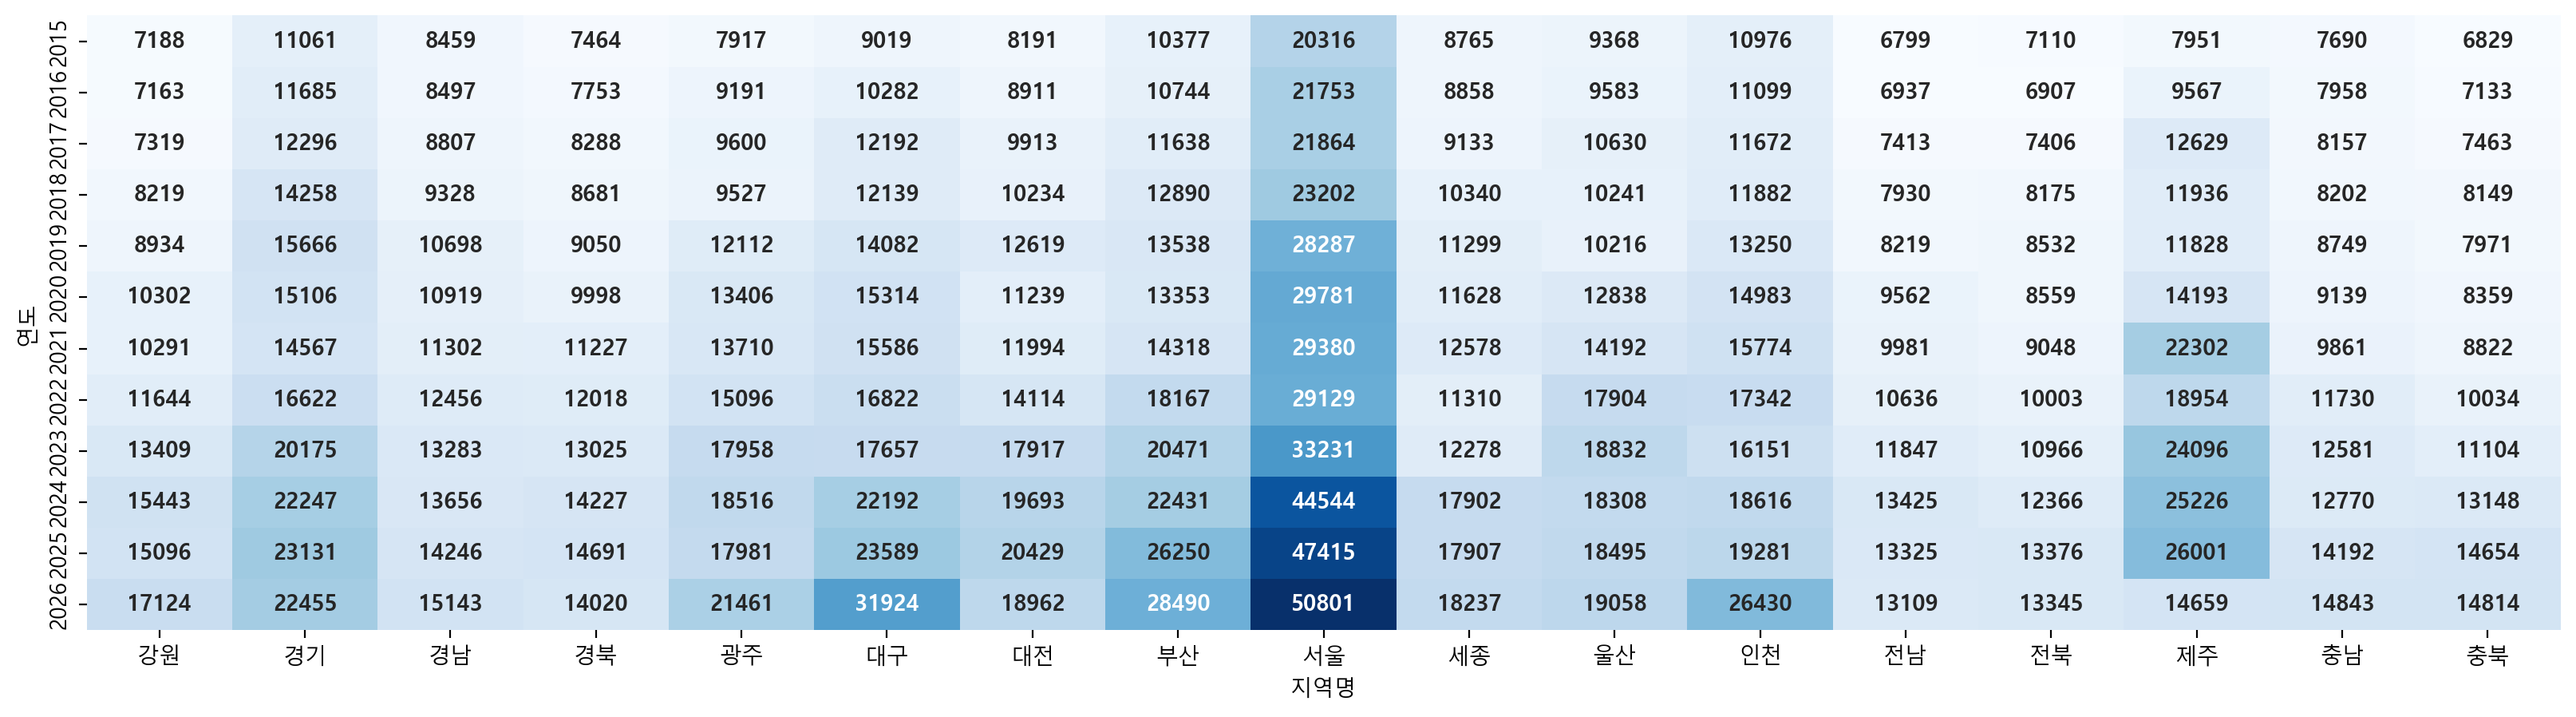

In [234]:
plt.figure(figsize=(20,5))
sns.heatmap(r, annot=True, fmt='.0f', cmap='Blues', cbar=False,
           annot_kws={'weight':'bold'})
plt.show()

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

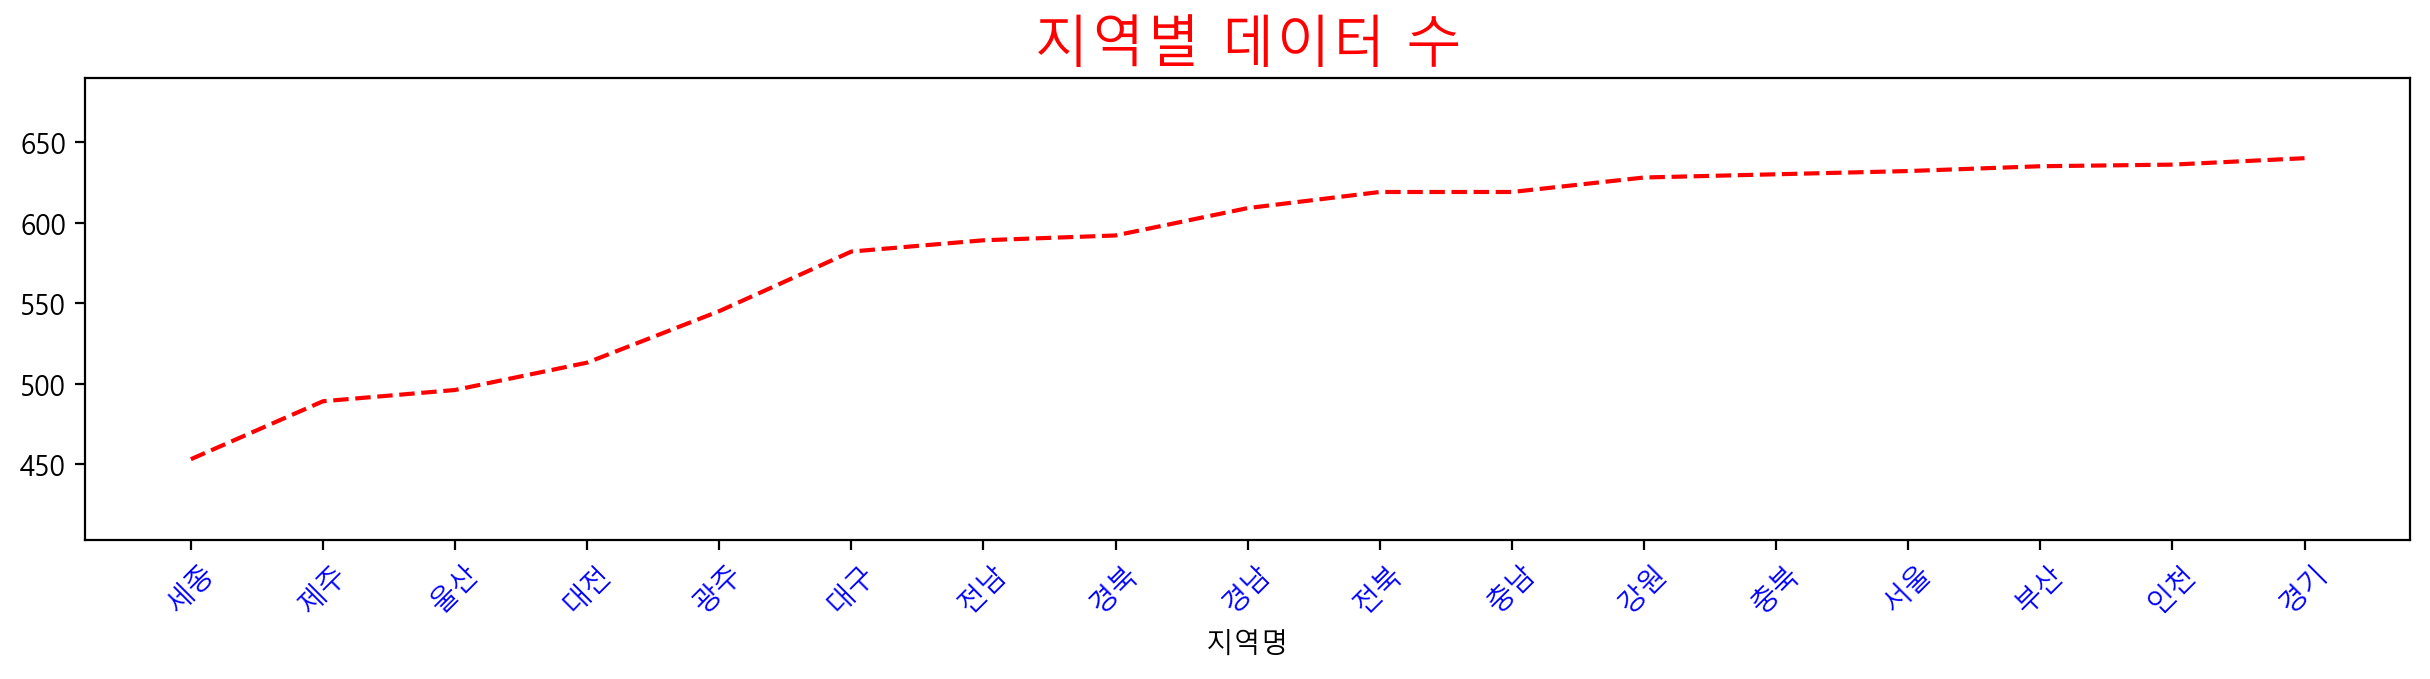

In [258]:
# plt.figure(figsize=(15,3))
plt.rcParams['figure.figsize'] = (15,3)
result = df_last.groupby('지역명')['평당분양가격'].count().sort_values()
# result.plot.line()
ax = result.plot(kind='line', color='r', linestyle='--', rot=45,
           #ylim=[result.min()-50, result.max()+50],
           #title='지역별 데이터 수'
           )
plt.title('지역별 데이터 수', color='#FF0000', size=20)
plt.ylim([result.min()-50, result.max()+50]) # 축범위
plt.xticks(range(len(result))) # 축눈금
ax.set_xticklabels(result.index, color='b') #눈금라벨
plt.show()

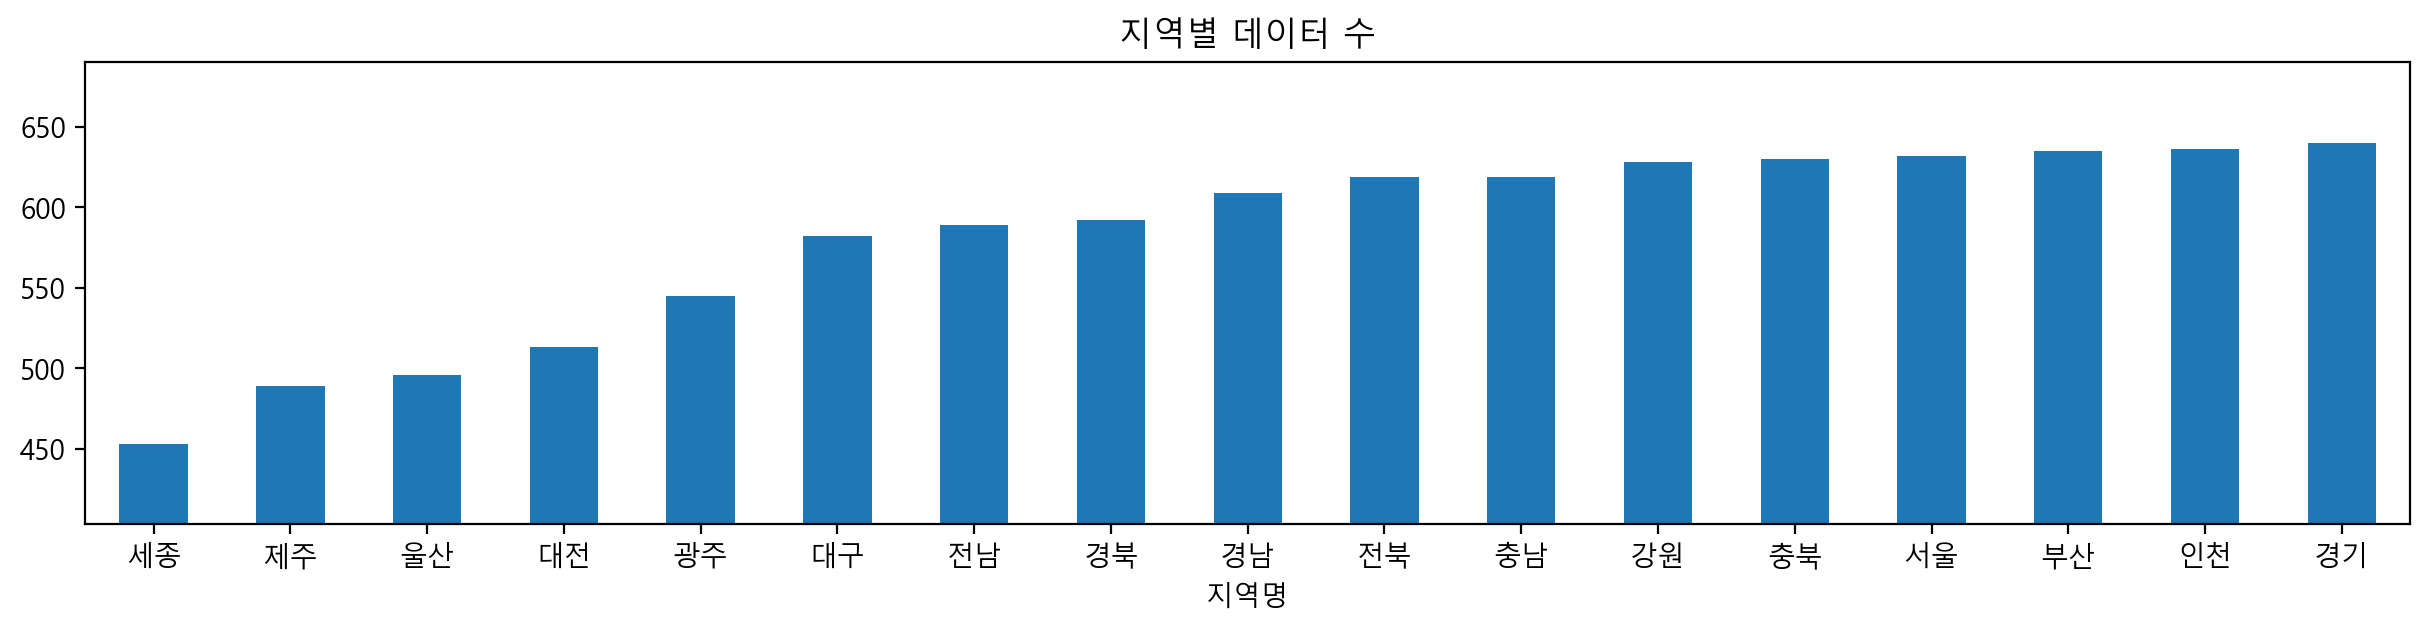

In [264]:
result.plot.bar(rot=0, #figsize=(15,3)
               title='지역별 데이터 수',
               ylim=[result.min()-50, result.max()+50])
# result.plot(kind='bar')
plt.show()

## (2) 지역별 평당분양가격 (line, bar)

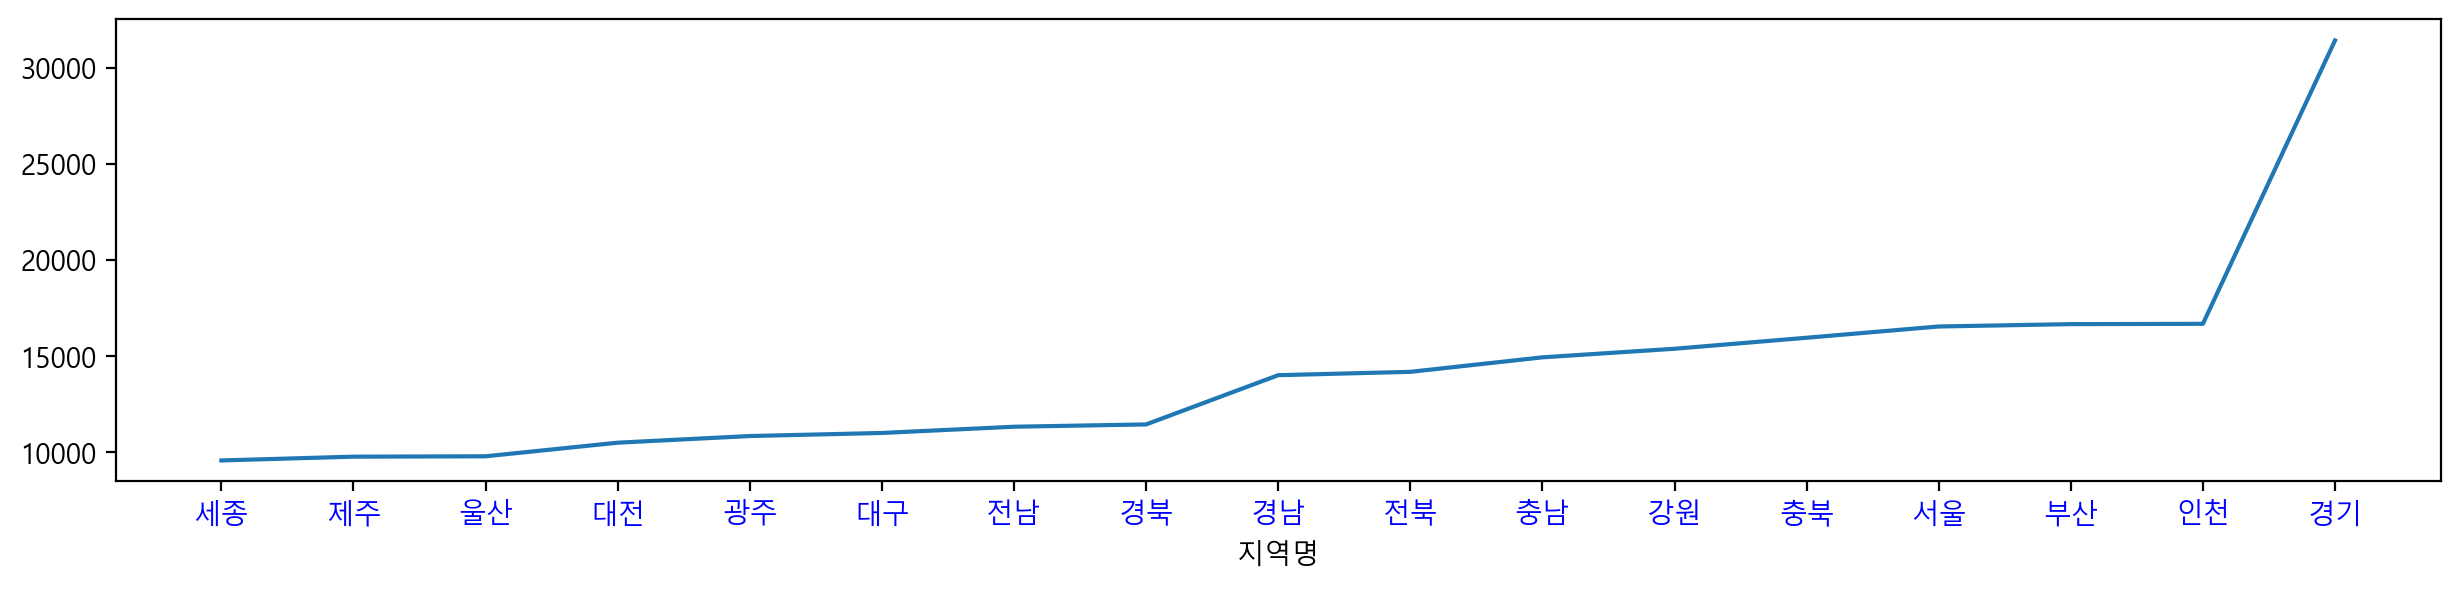

In [267]:
ax = df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='line')
plt.xticks(range(len(result))) # 축눈금
ax.set_xticklabels(result.index, color='b') #눈금라벨
plt.show()

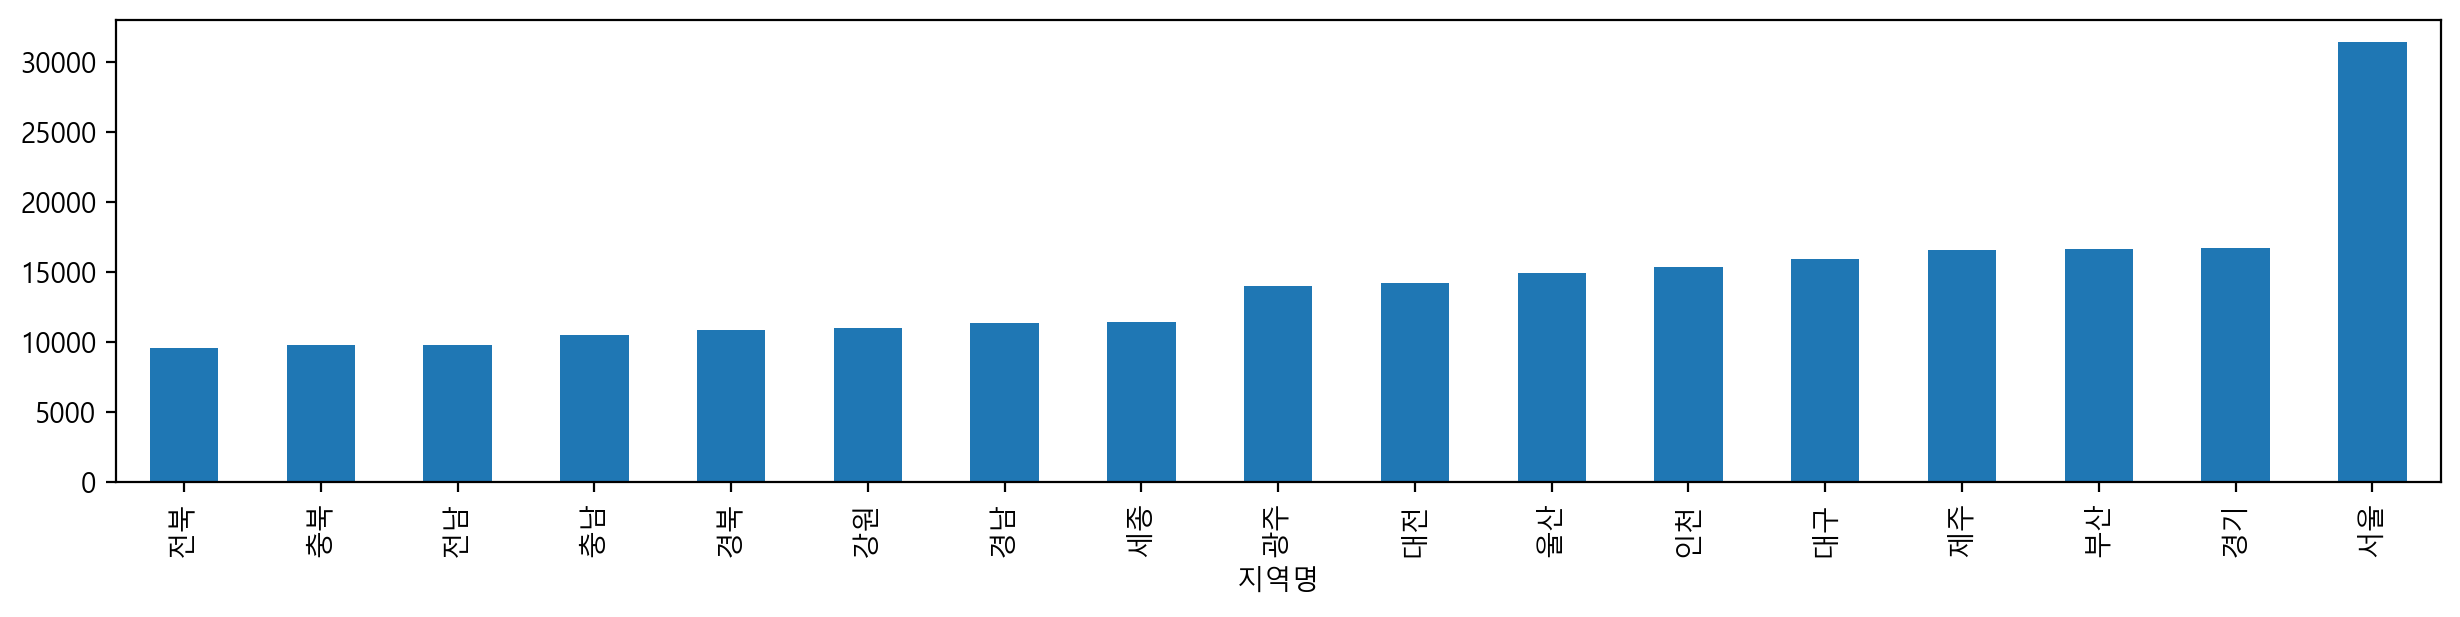

In [268]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='bar')
plt.show()

## (3) 전용면적별 평당분양가격(barplot)

In [285]:
order = ['60m','60m~85m','85m~102m','102m~','모든면적']
result = df_last.groupby('전용면적')['평당분양가격'].mean().reindex(order)
result

전용면적
60m         13553.346590
60m~85m     13710.910108
85m~102m    14554.491727
102m~       15348.875445
모든면적        13783.366324
Name: 평당분양가격, dtype: float64

In [286]:
for i, val in enumerate(result):
    print(i, val)

0 13553.34658976931
1 13710.910107627515
2 14554.491726618704
3 15348.875444839858
4 13783.366324147595


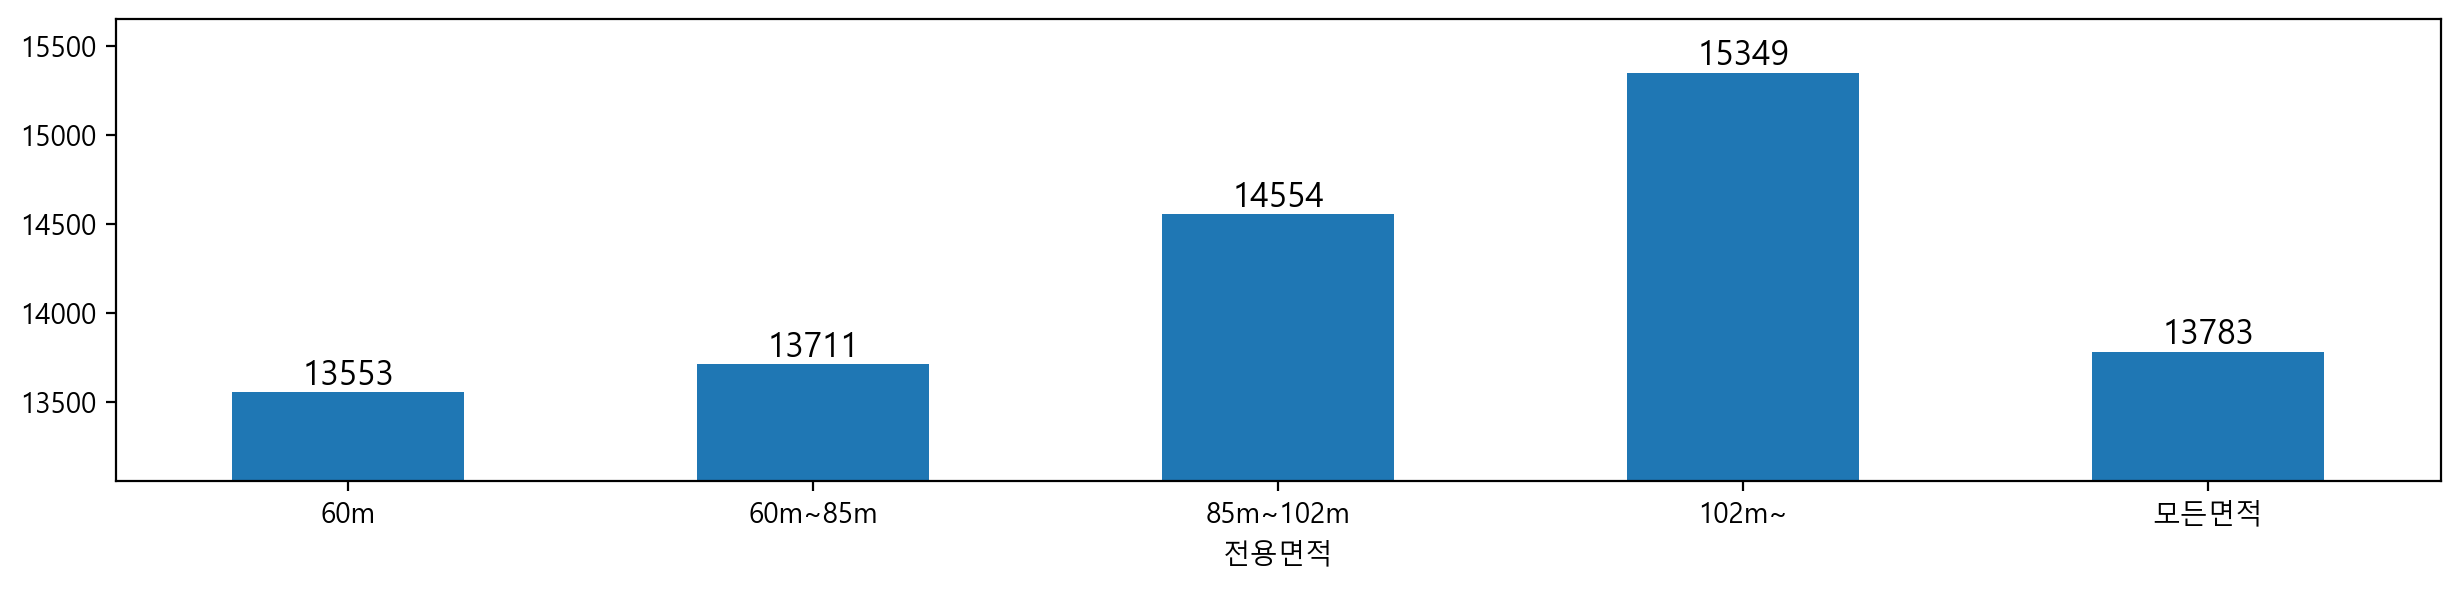

In [296]:
result.plot(kind='bar',
            rot=0,
            ylim=[result.min()-500, result.max()+300])
for i, val in enumerate(result):
    #plt.text(i-0.1, val+70, round(val), fontsize=12)
    # va:수직정렬, ha:수평정렬
    plt.text(i, val, round(val), fontsize=12, va='bottom', ha='center')
plt.show()

## (4) 연도별 평균 평당분양가격(line)

In [301]:
result = df_last.groupby('연도')['평당분양가격'].mean()
for year, val in result.items():
    print(year, val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105265
2020 13039.42244897959
2021 13636.02253968254
2022 14942.504494382023
2023 16890.92065677966
2024 19193.25543859649
2025 20058.10582306831
2026 21111.42526595745


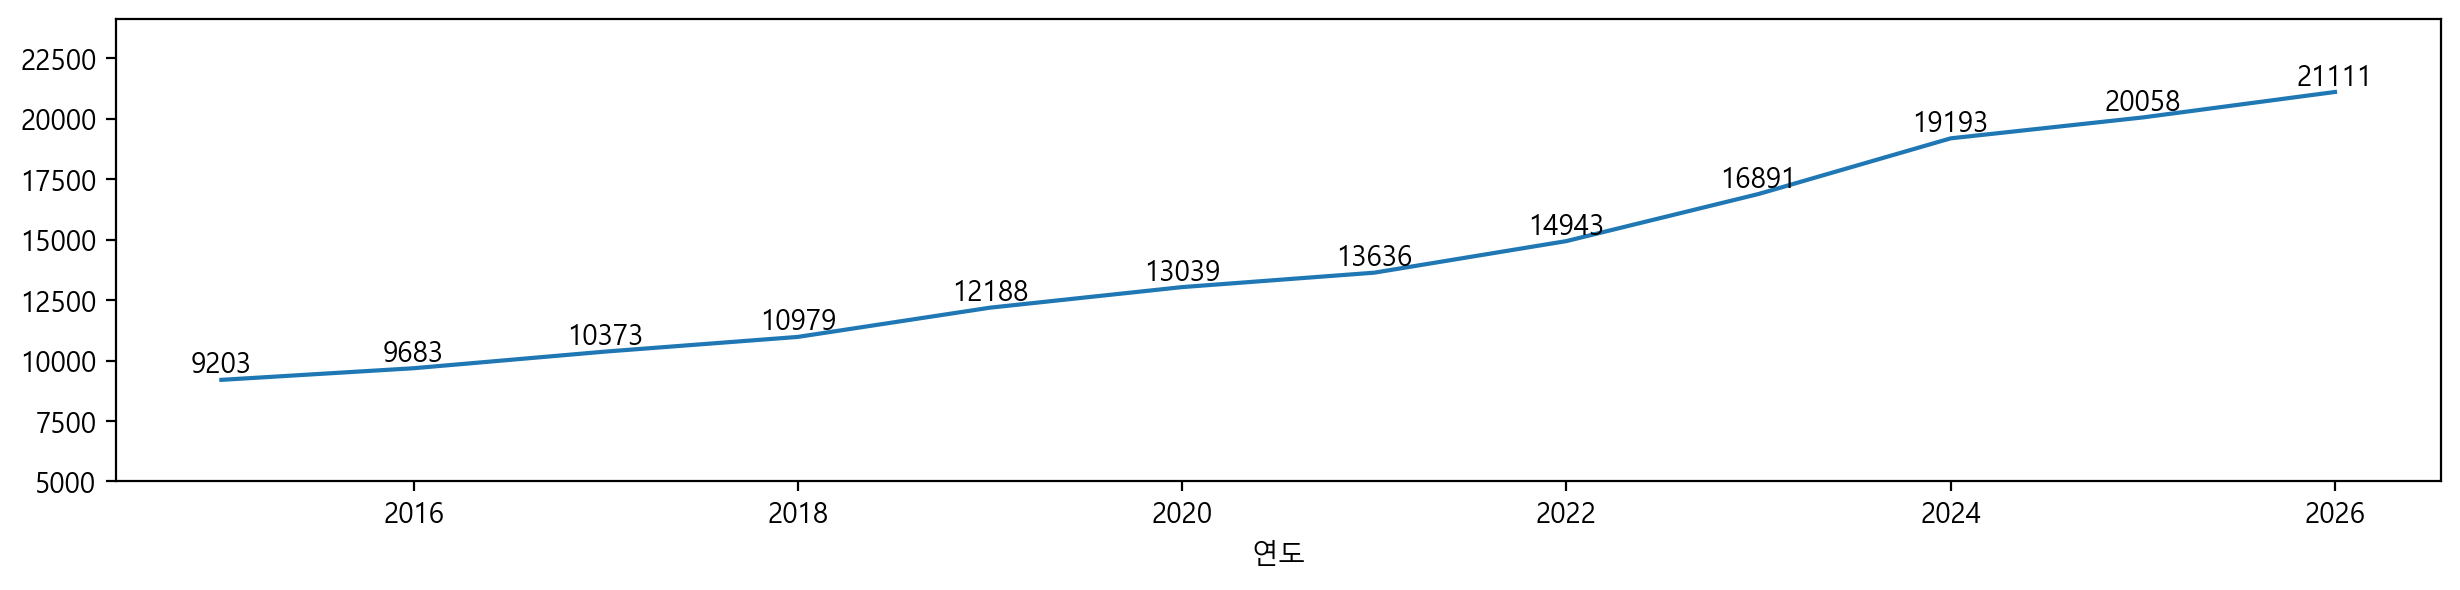

In [307]:
result.plot(kind='line',
           ylim=[5000, result.max()+3000])
for year, val in result.items():
    plt.text(year, val, round(val), va='bottom', ha='center')

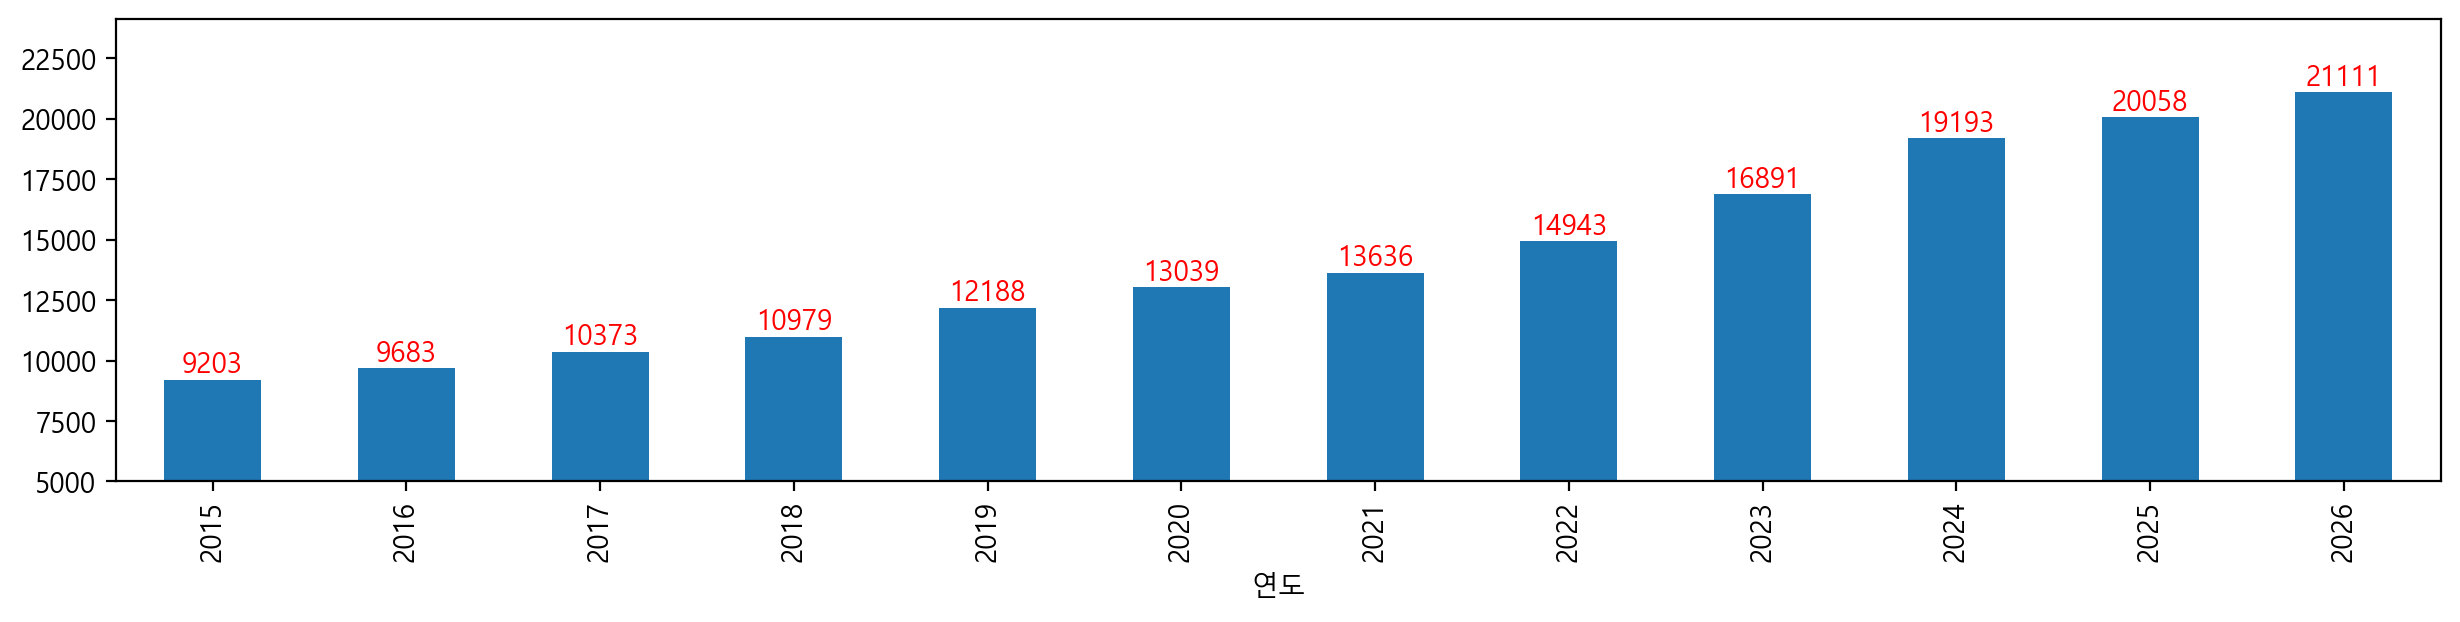

In [311]:
result.plot(kind='bar',
           ylim=[5000, result.max()+3000])
for i, val in enumerate(result):
    plt.text(i, val, round(val), va='bottom', ha='center', color='r')

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [325]:
sns.set(style='white', rc={'figure.figsize':(15,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

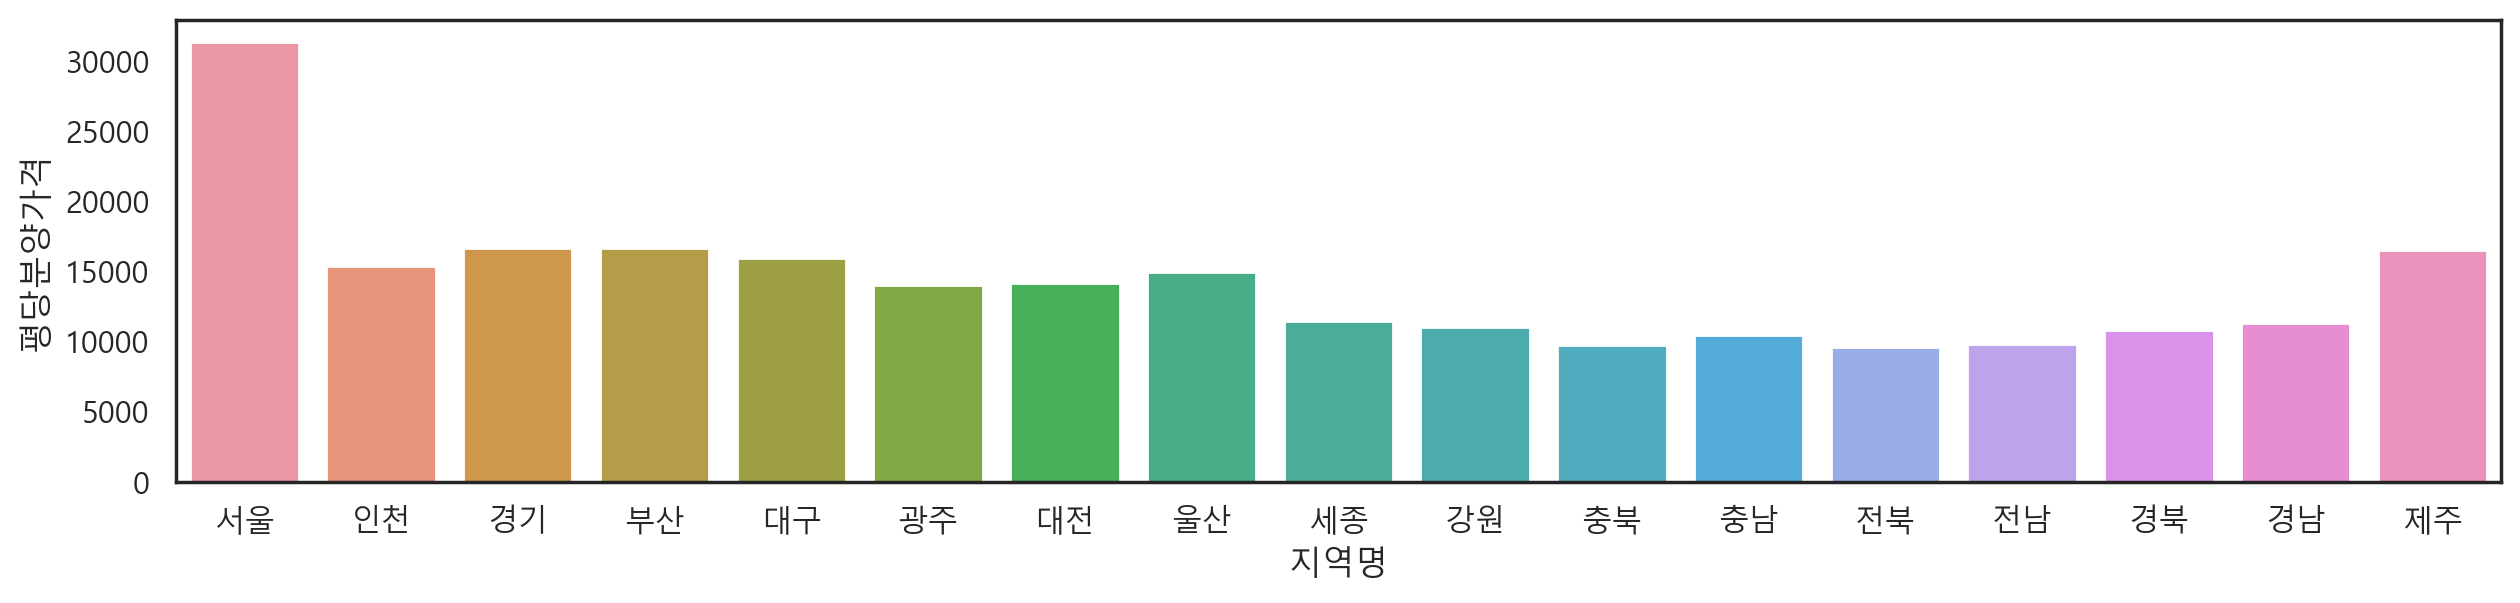

In [326]:
sns.barplot(data=df_last, x='지역명', y='평당분양가격', errorbar=None
           )
plt.show()

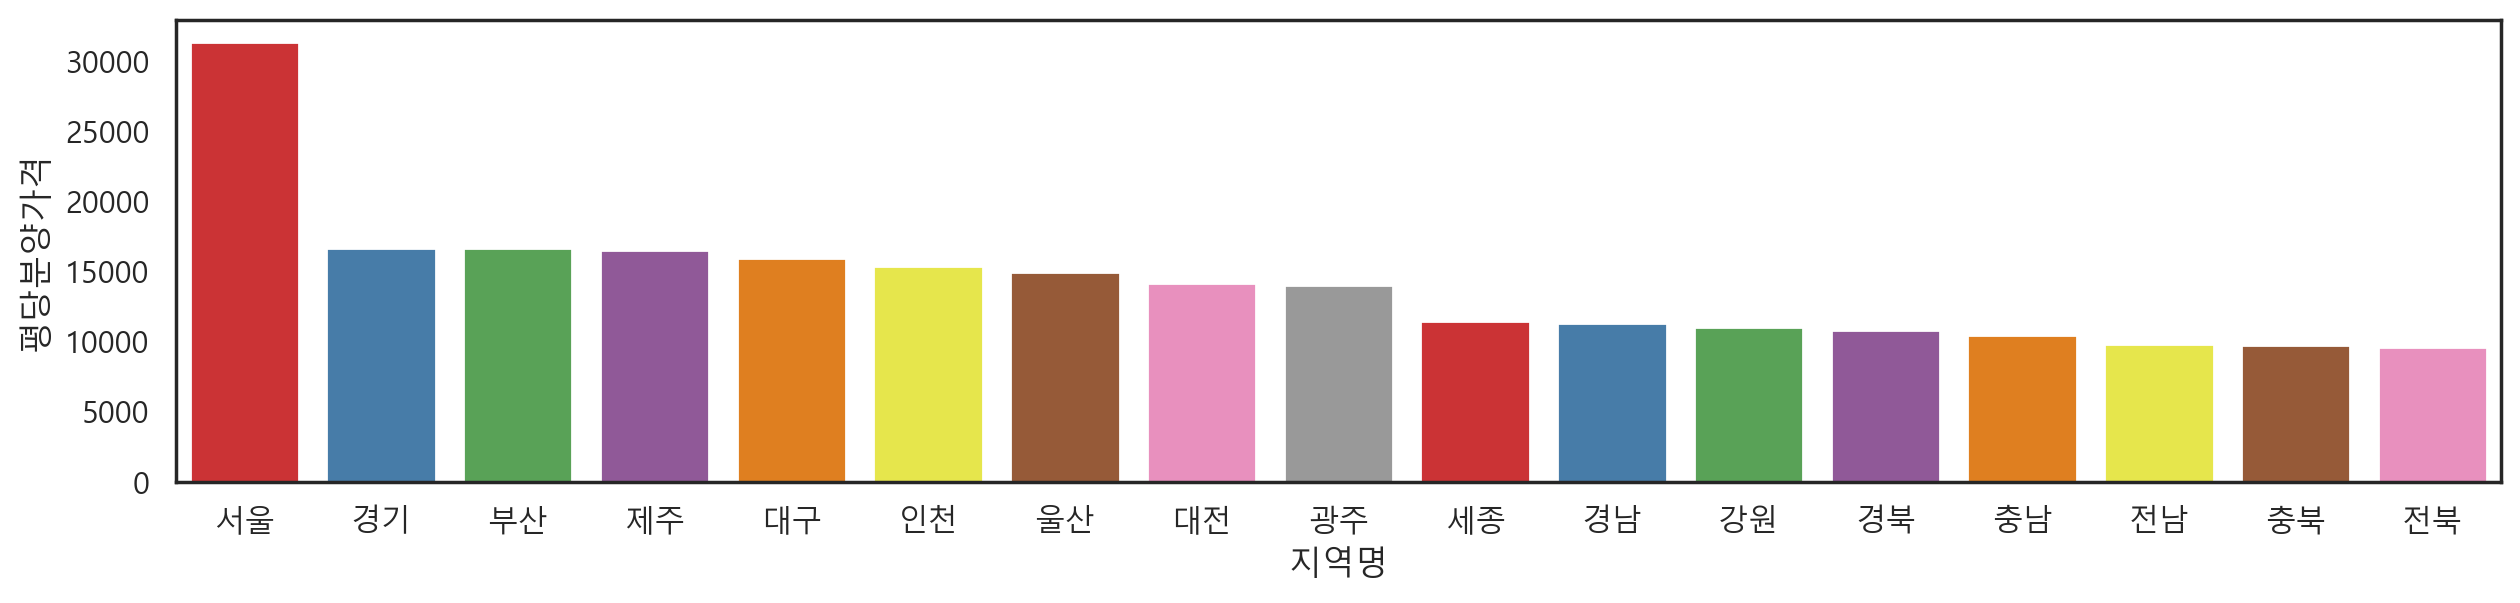

In [328]:
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='지역명', y='평당분양가격', errorbar=None,
           order=result.index, palette='Set1')
plt.show()

In [330]:
for i, val in enumerate(result):
    print(i, val)

0 31416.731012658227
1 16675.7765625
2 16658.924881889765
3 16536.99509202454
4 15951.406185567012
5 15378.612264150945
6 14932.213911290322
7 14177.752046783626
8 14003.631743119266
9 11442.134437086093
10 11322.646798029557
11 10998.011942675159
12 10838.521114864865
13 10492.272697899838
14 9784.729711375212
15 9765.255238095238
16 9568.656542810986


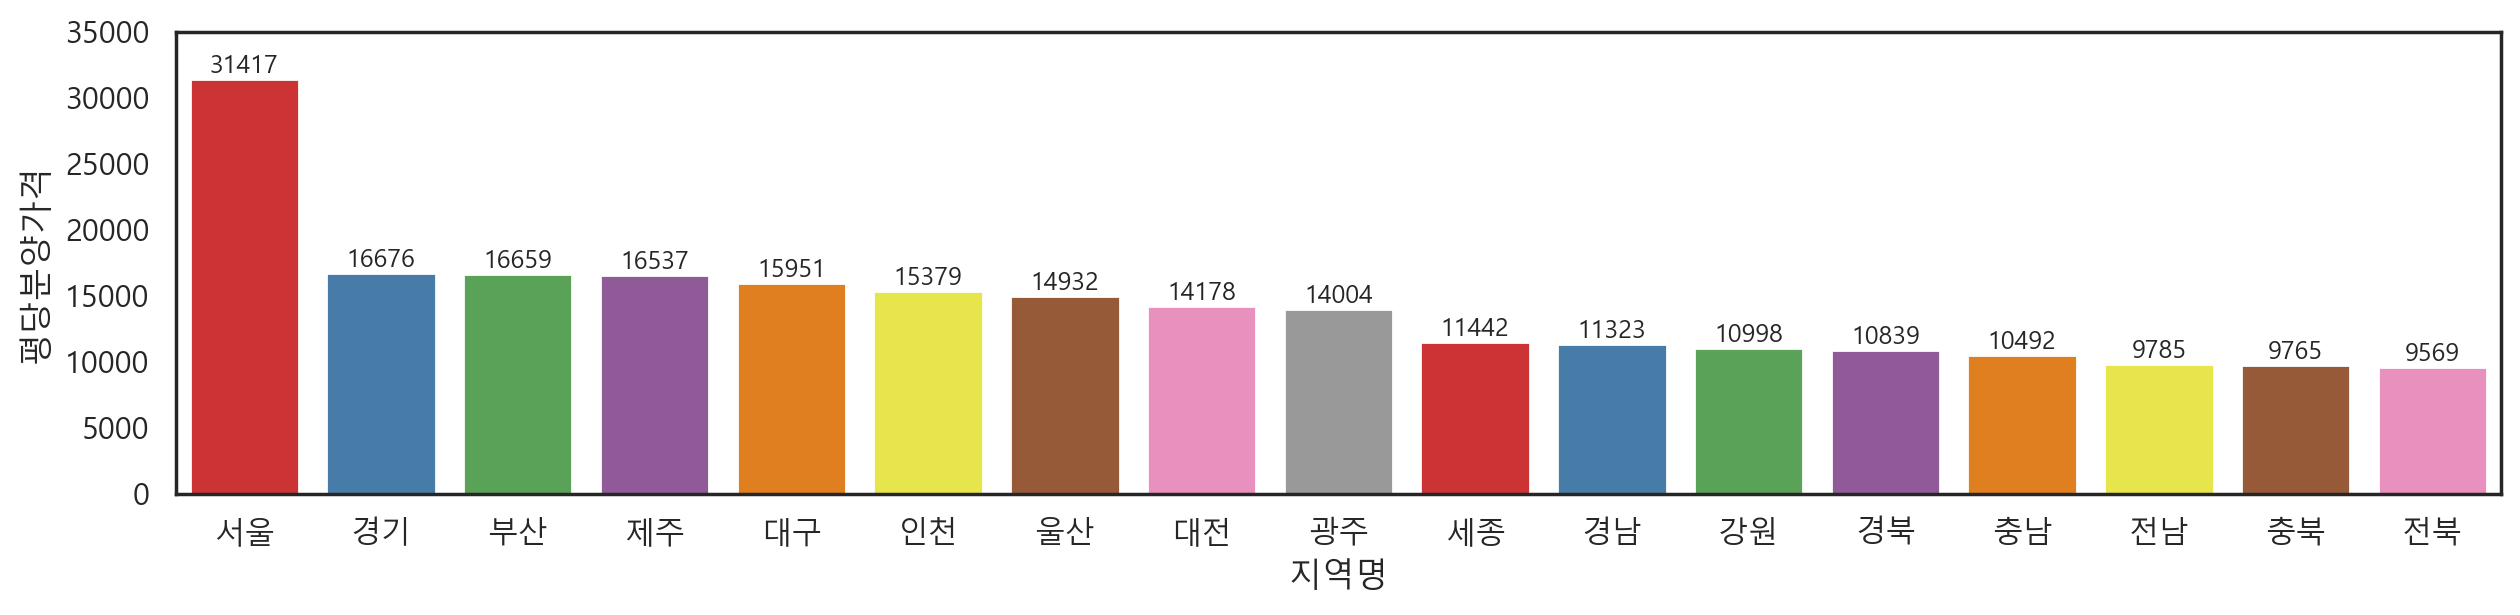

In [338]:
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='지역명', y='평당분양가격', errorbar=None,
           order=result.index, palette='Set1')
plt.ylim([0, 35000])
for i, v in enumerate(result):
    plt.text(i, v, round(v), va='bottom', ha='center', fontsize=9)
plt.show()

## (2) 연도별 평당분양가격

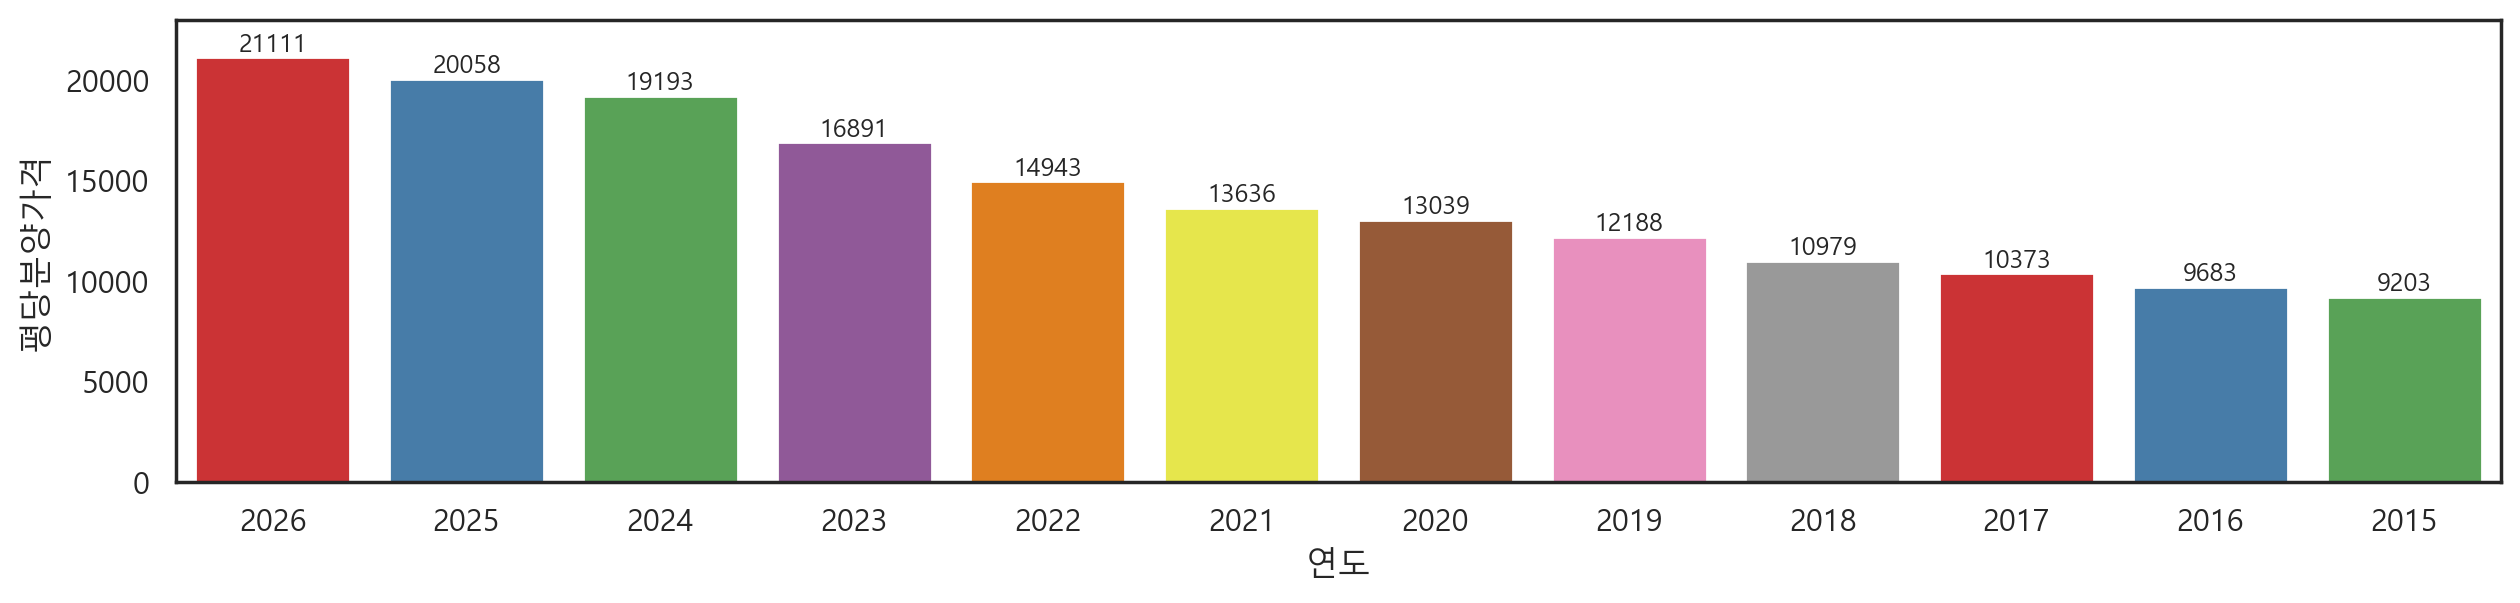

In [344]:
result = df_last.groupby('연도')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='연도', y='평당분양가격', errorbar=None,
           order=result.index, palette='Set1')
plt.ylim([0, 23000])
for i, v in enumerate(result):
    plt.text(i, v, round(v), va='bottom', ha='center', fontsize=9)
plt.show()

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

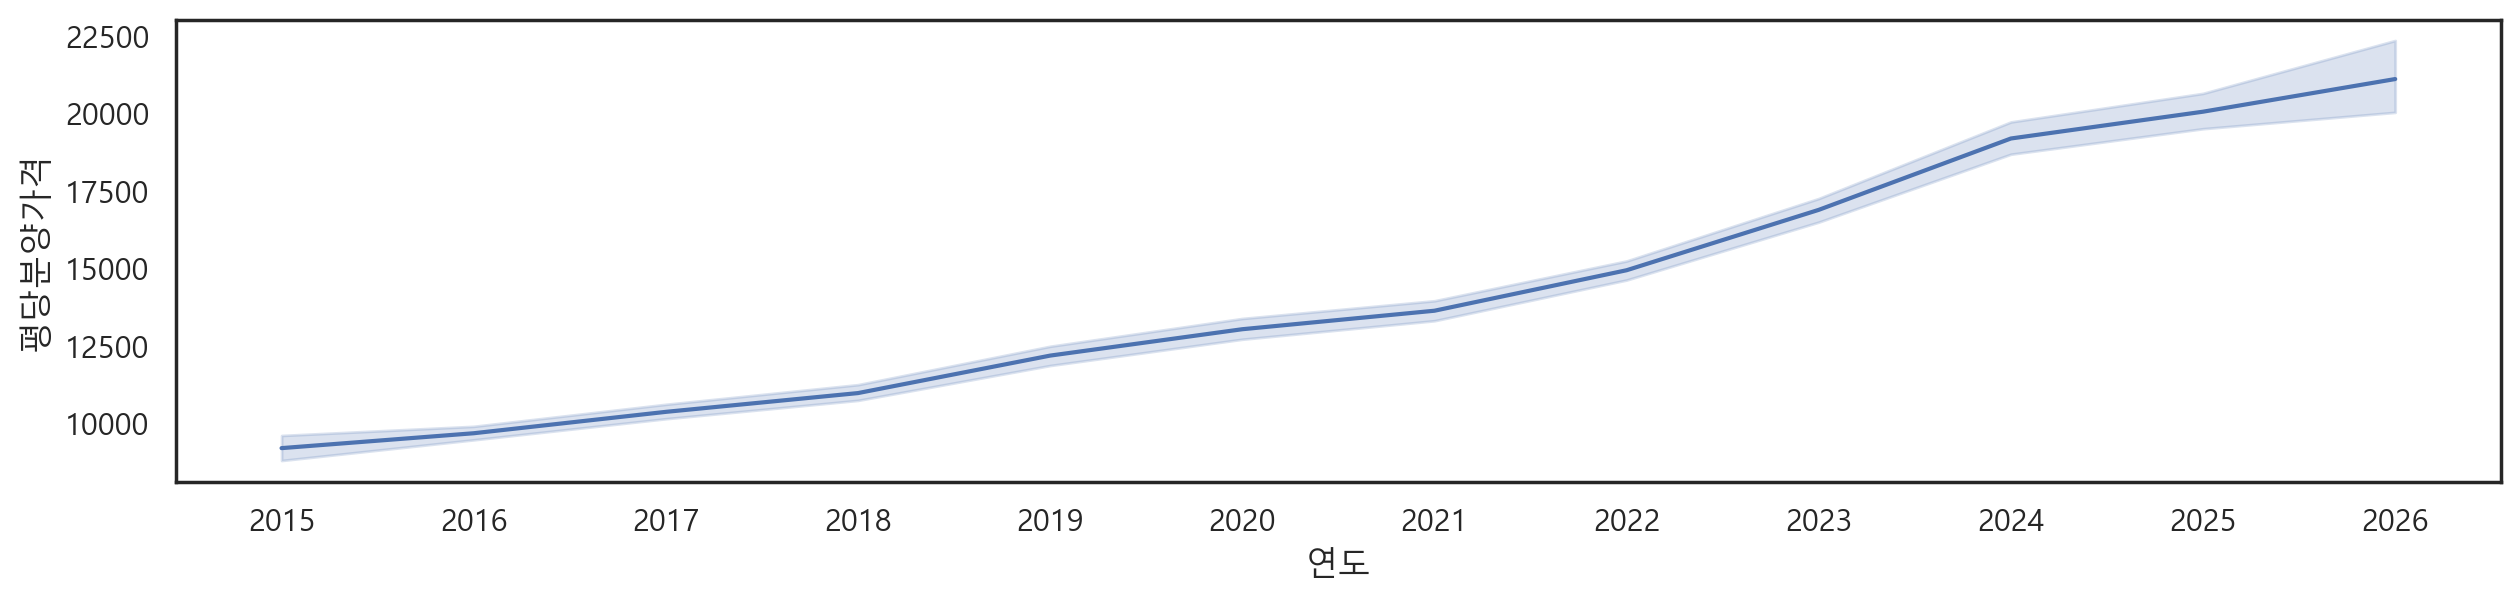

In [346]:
# 년도별 평균 분양가격 추이
sns.lineplot(data=df_last, x='연도', y='평당분양가격')
plt.xticks(range(2015,2027))
plt.show()

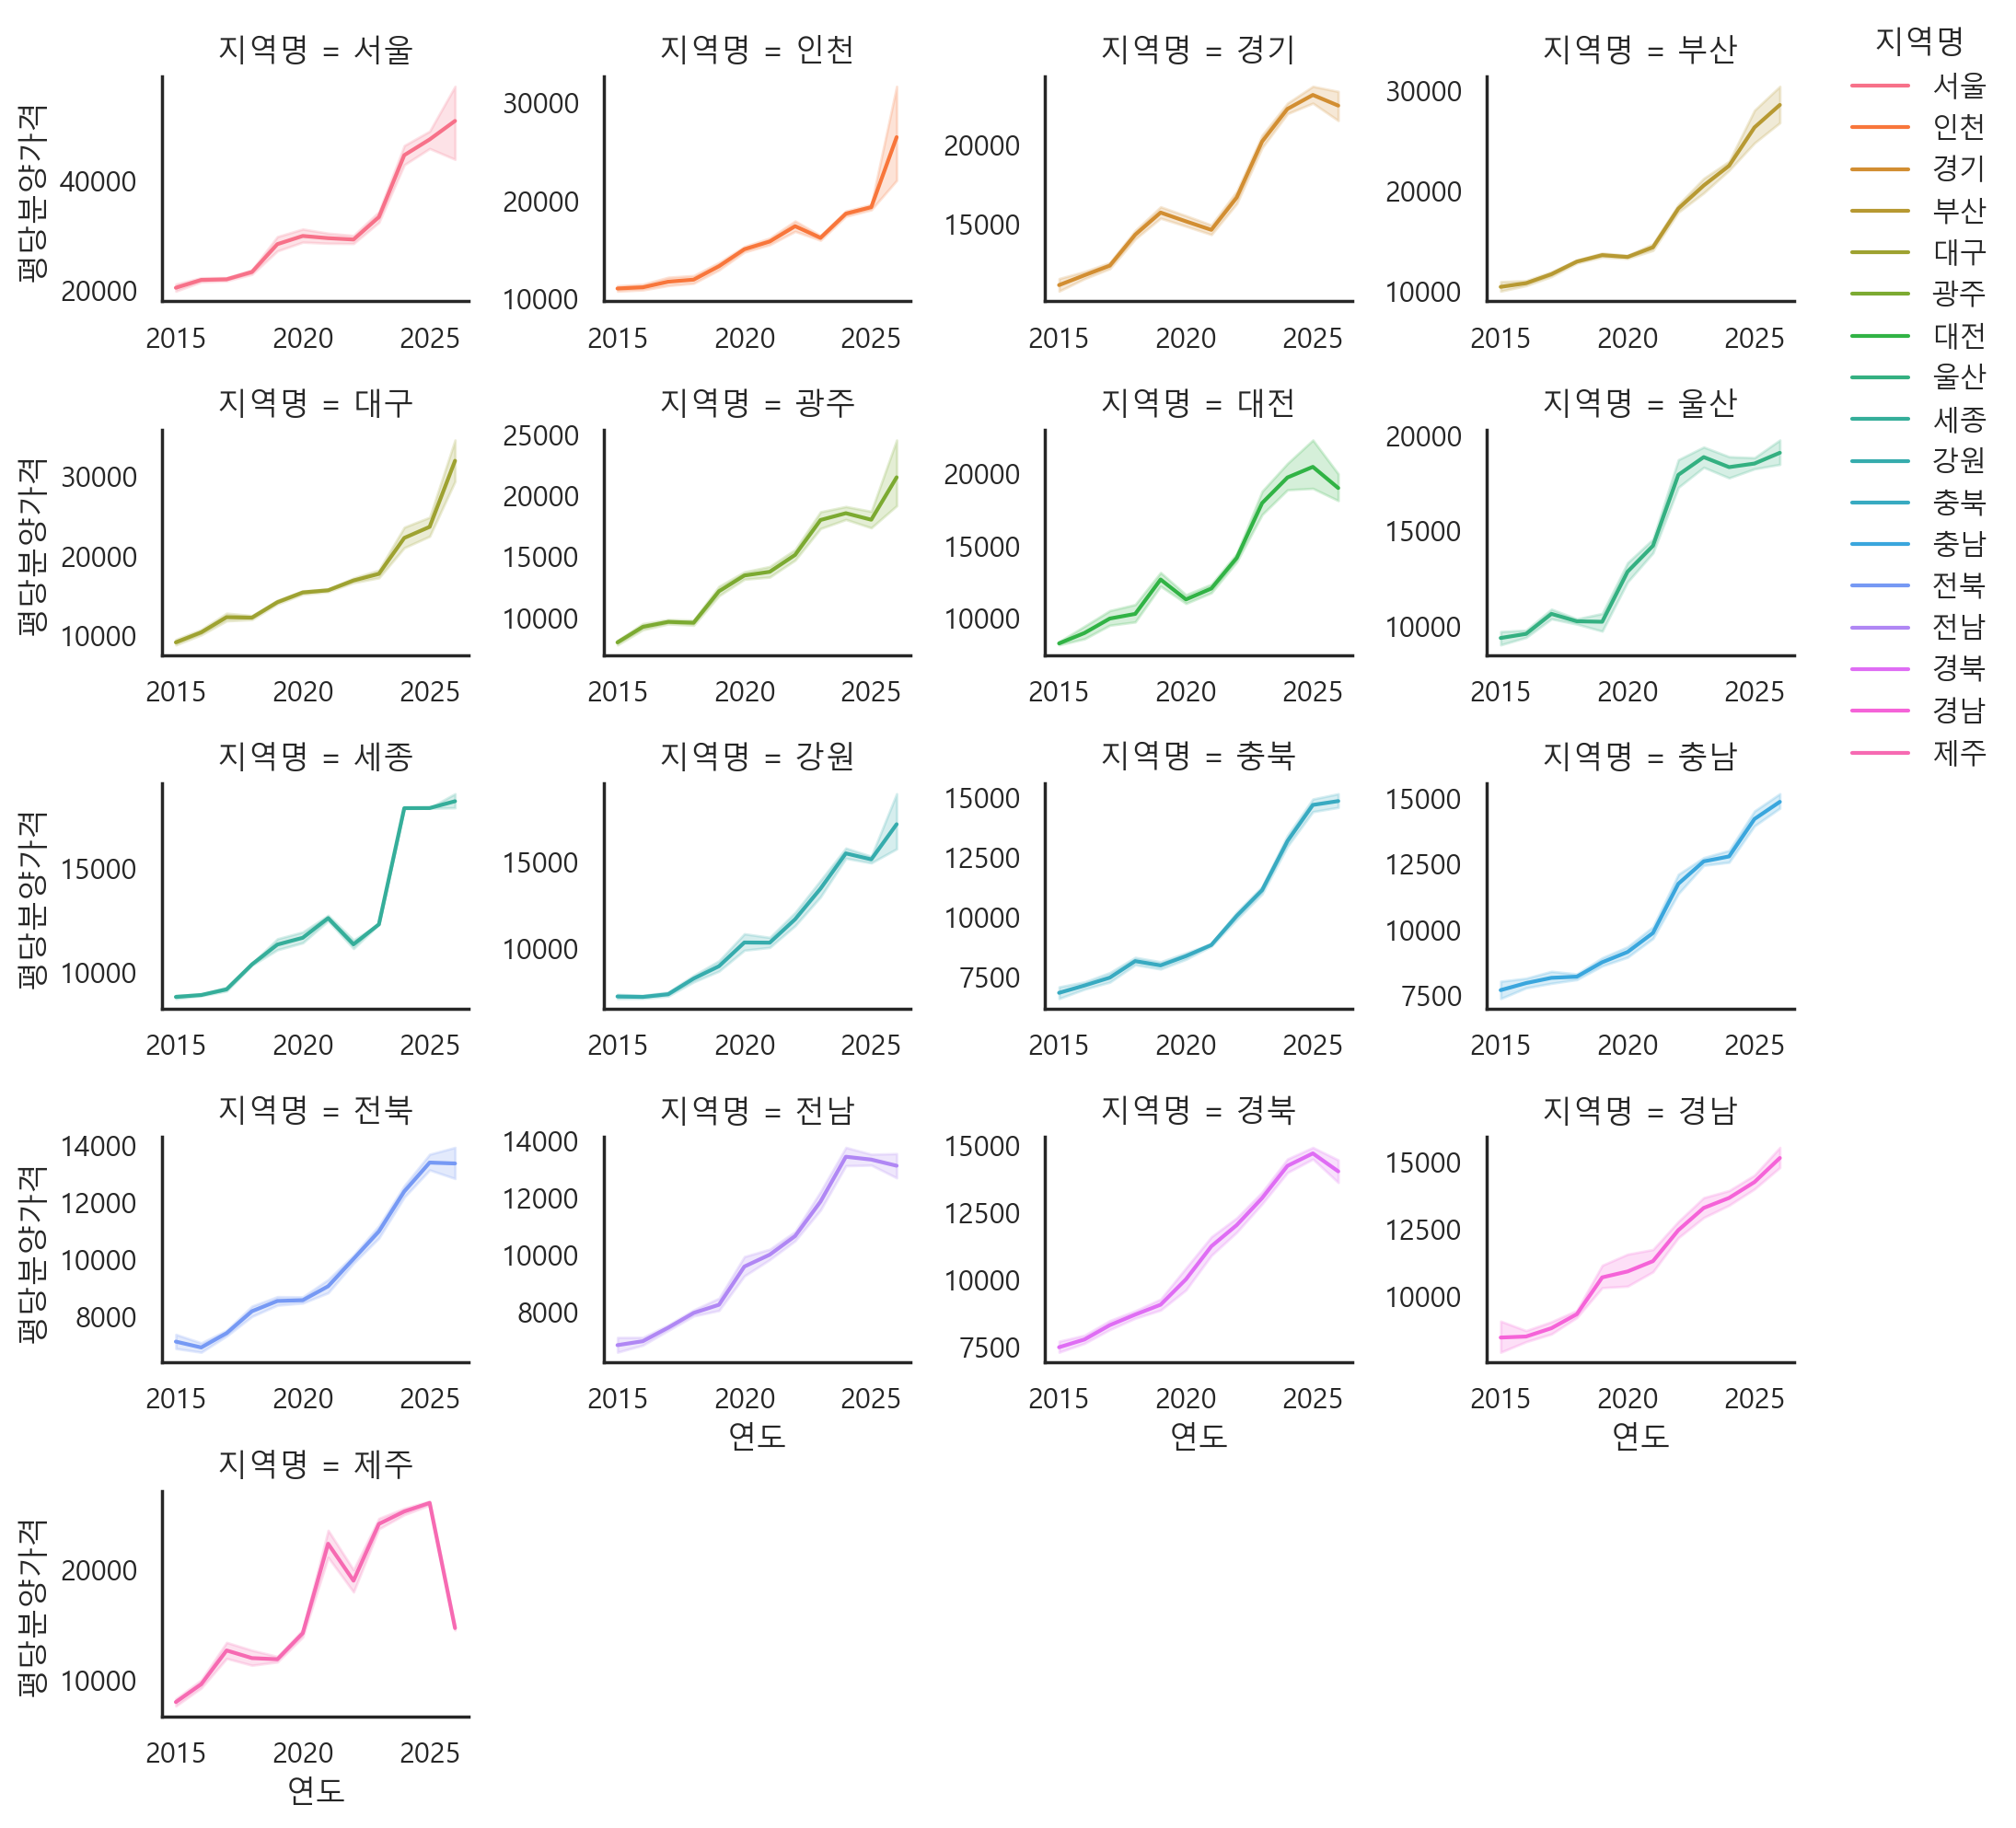

In [355]:
# 년도별, 지역별 평당분양가격을 지역별로 서브플롯(relplot)
g = sns.relplot(data=df_last,
               x='연도',
               y='평당분양가격',
               kind='line',
               hue='지역명',
               col='지역명',
               col_wrap=4,
               facet_kws={'sharex':False, 'sharey':False})
g.fig.set_size_inches(10,10)
plt.tight_layout()
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.show()

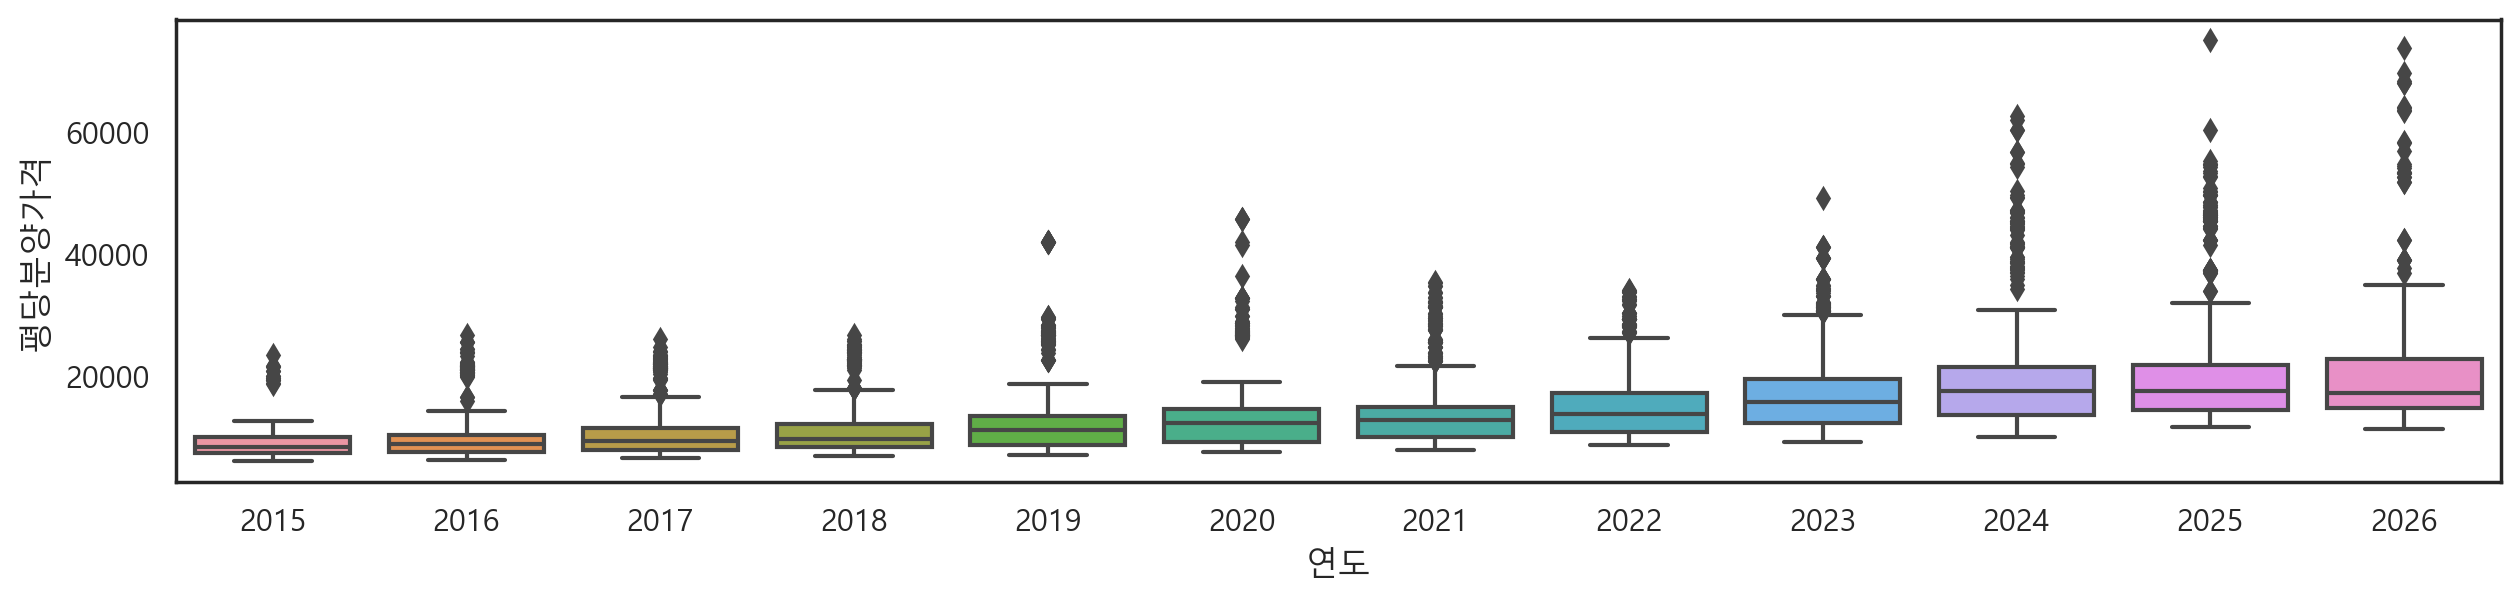

In [357]:
# 연도별 평당분양가격의 boxplot, violinplot, boxexplot
sns.boxplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

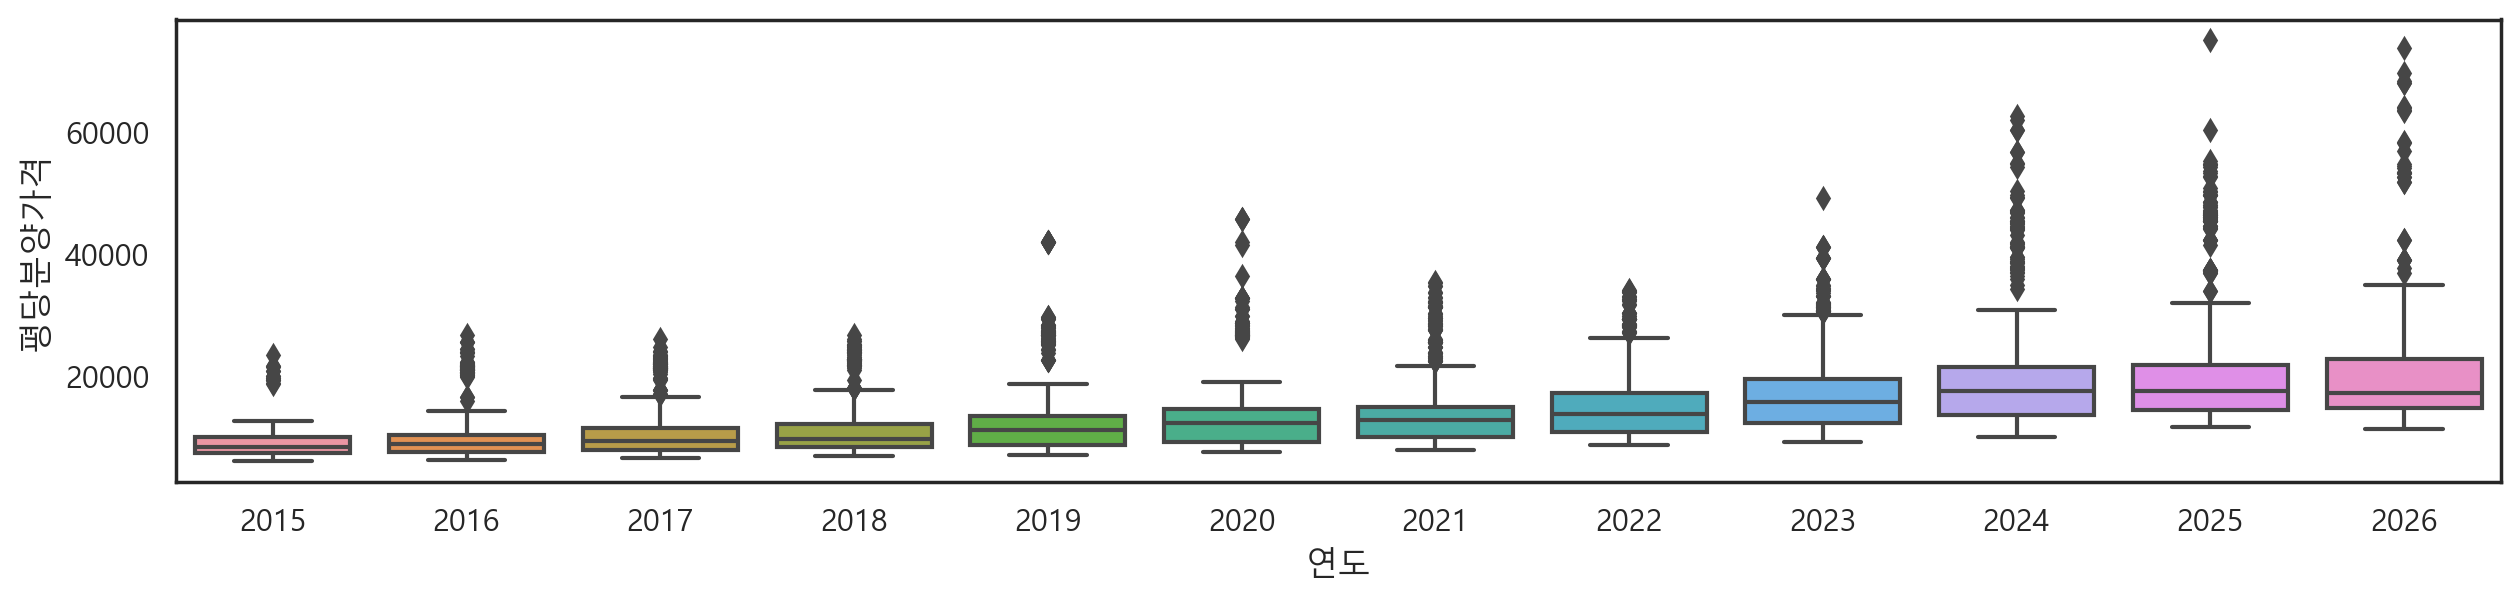

In [358]:
# 연도별 평당분양가격의 boxplot, violinplot, boxexplot
sns.boxplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

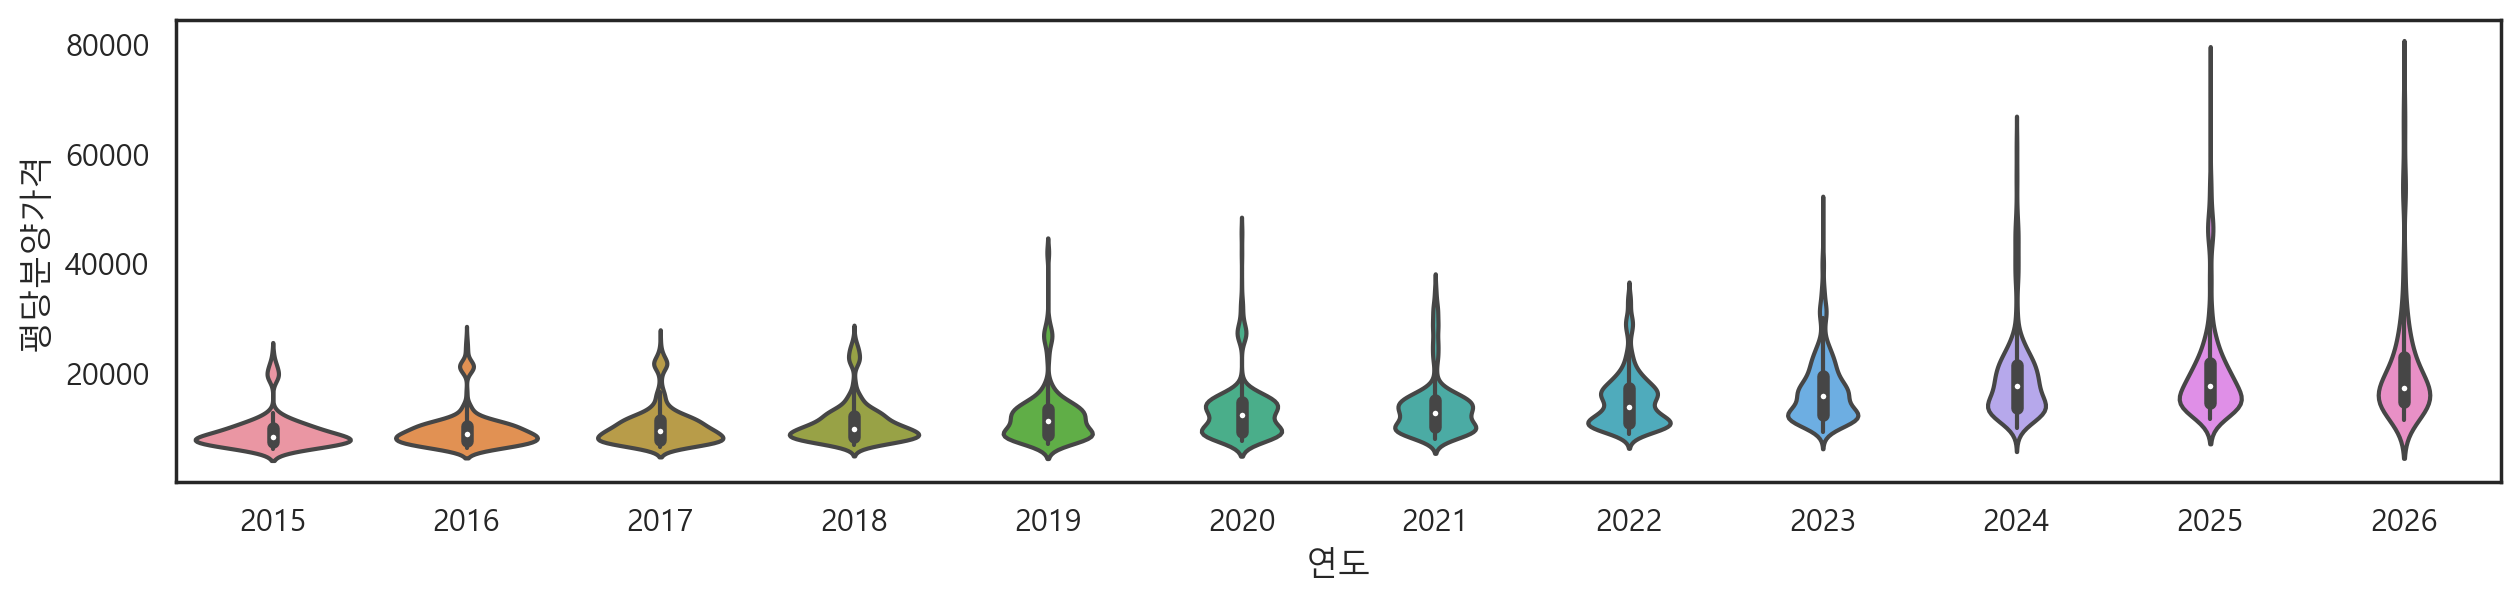

In [359]:
sns.violinplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

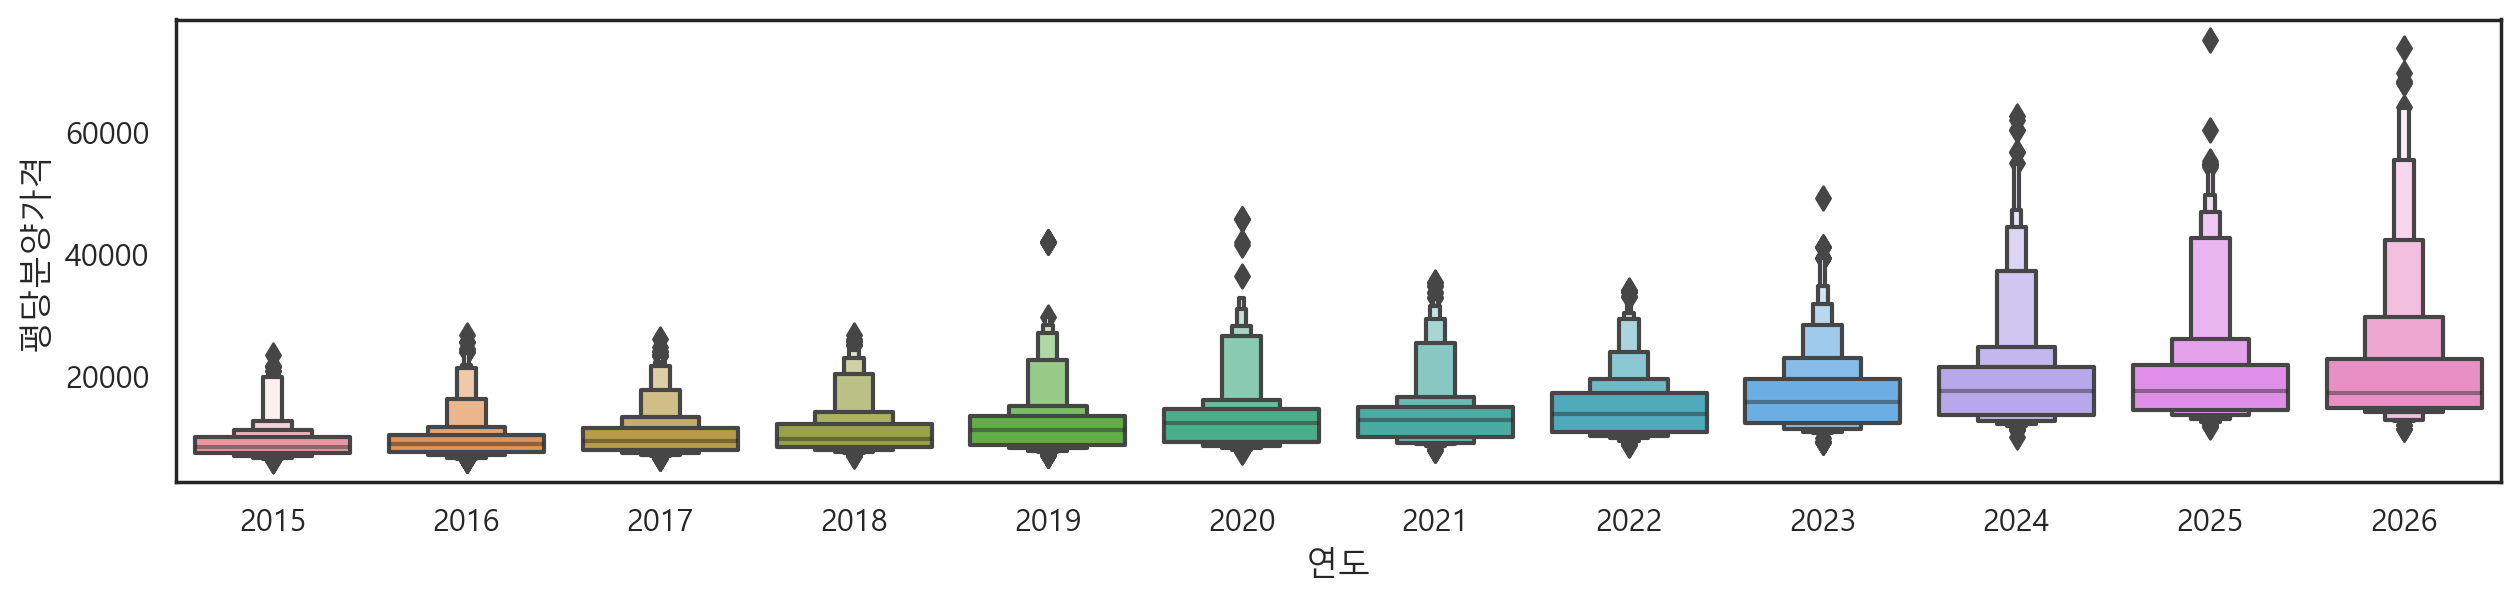

In [360]:
sns.boxenplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

In [427]:
%%time
# 연도별 평당분양가격 산점도
# sns.swarmplot(data=df_last, x='연도', y='평당분양가격', size=1)
# plt.show()

CPU times: total: 0 ns
Wall time: 0 ns


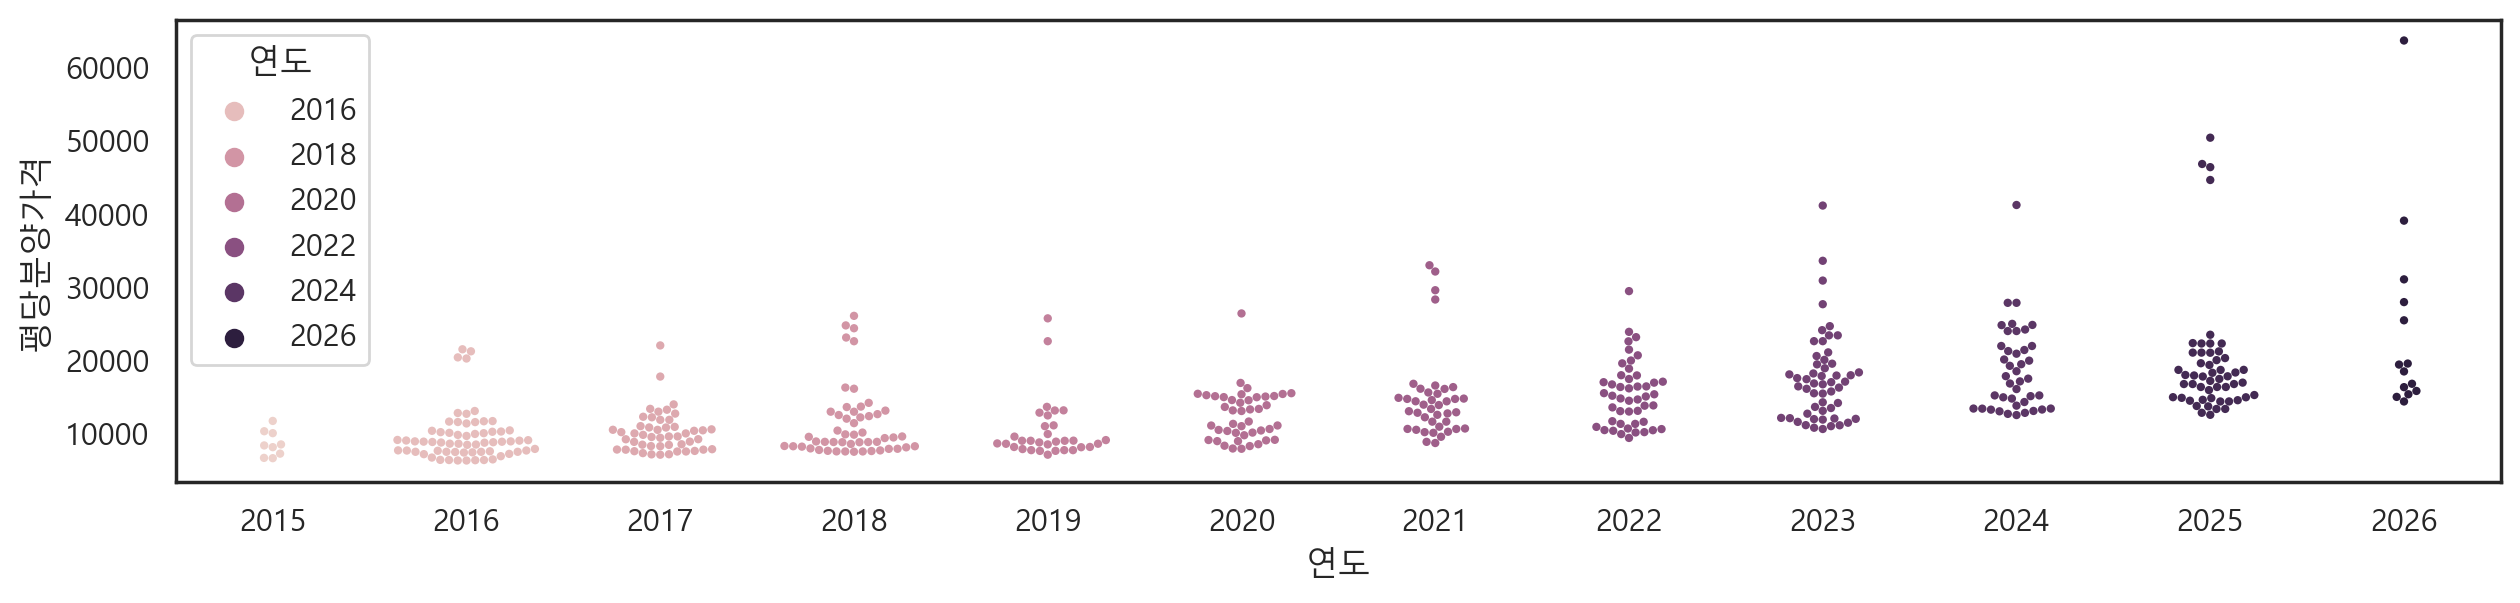

CPU times: total: 844 ms
Wall time: 844 ms


In [370]:
%%time
# df_last.sample(frac=0.05) #fraction 비율
sns.swarmplot(data=df_last.sample(frac=0.05), x='연도', y='평당분양가격', size=3, hue='연도')
plt.show()

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

In [373]:
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [374]:
new_first = df_first.melt(id_vars='지역',
                         var_name='연도월',
                         value_name='평당분양가격')
new_first.head(1)

,지역,연도월,평당분양가격
0,서울,2013년12월,18189


In [380]:
# map이나 apply를 이용해서 연도와 월 컬럼 추가
new_first['연도'] = new_first['연도월'].apply(lambda x : int(x.split('년')[0]) )
new_first.head(1)

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013


In [387]:
new_first['연도월'].apply(lambda x : int(x.split('년')[1].replace('월','')))
new_first['월'] = new_first['연도월'].apply(lambda x : int(x.split('년')[1][:-1]))
new_first.sample()

,지역,연도월,평당분양가격,연도,월
71,인천,2014년4월,10000,2014,4


In [390]:
# 연도월컬럼을 drop(pop), 지역컬럼을 지역명으로 컬럼명 수정
new_first = new_first.drop('연도월', axis=1)
new_first.sample()

,지역,평당분양가격,연도,월
283,충남,7017,2015,4


In [392]:
# new_first.columns = ['지역명','평당분양가격','연도','월']
new_first.rename(columns={'지역':'지역명'}, inplace=True)
new_first.sample()

,지역명,평당분양가격,연도,월
65,경북,6317,2014,3


In [398]:
# new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
 #               (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)
new_last = df_last[df_last['전용면적']=='모든면적']
new_last = new_last.drop('전용면적', axis=1)
new_last.head(1)

,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3


In [406]:
# new_first와 new_last를 연결
df = pd.concat([new_first, new_last], axis=0).reset_index(drop=True)
df.shape

(2533, 4)

## (2) 결측치 대체(연도별, 지역별 중위값)

In [413]:
df[df['평당분양가격'].isna()].head(1)

,지역명,평당분양가격,연도,월
1010,울산,NaN,2018,12


In [420]:
# 연도별 지역별 평당분양가격 중위값
fillnavalue = df.groupby(['연도','지역명'])['평당분양가격'].median().unstack()
fillnavalue = df.pivot_table(index='연도', columns='지역명', values='평당분양가격', aggfunc='median')
fillnavalue.loc[2018,'울산']

10312.5

In [421]:
def fillna_median(row):
    row = row.copy()
    year = row['연도']
    loc  = row['지역명']
    # np.isnan(값), pd.isna(값), pd.isnull(값)
    if np.isnan(row['평당분양가격']):
        row['평당분양가격'] = fillnavalue.loc[year, loc]
    return row
fillna_median(df.loc[1010])

지역명            울산
평당분양가격    10312.5
연도           2018
월              12
Name: 1010, dtype: object

In [424]:
df = df.apply(fillna_median, axis=1)
df.isna().sum()

지역명       0
평당분양가격    0
연도        0
월         0
dtype: int64

## (3) df.csv파일로 출력

In [426]:
df.to_csv('data/df(최종).csv', index=False)

In [ ]:
df

## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [ ]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ③ 연도별 평당분양가격(평균)

In [ ]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
